Fold 1 AUC: 0.92310
Fold 2 AUC: 0.92239
Fold 3 AUC: 0.92100
Fold 4 AUC: 0.92191
Fold 5 AUC: 0.92147
\nOverall CV AUC: 0.92197

--- Top 20 Most Important Features ---
                                        feature    importance
0       annual_income_mean_by_employment_status  1.756574e+06
1                                  default_risk  5.680358e+05
2                          debt_to_income_ratio  1.533949e+05
3                                  credit_score  4.442635e+04
4                                grade_subgrade  3.546095e+04
5                                 interest_rate  1.905435e+04
6                          TE_employment_status  1.722218e+04
7                                   loan_amount  1.038214e+04
8                                 annual_income  8.453154e+03
9                               TE_loan_purpose  8.079768e+03
10                              loan_amount_d-2  7.969355e+03
11                            TE_grade_subgrade  7.948416e+03
12     loan_amount_ratio_to_

C:\Users\mateu\AppData\Local\Temp\ipykernel_9992\2344909851.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


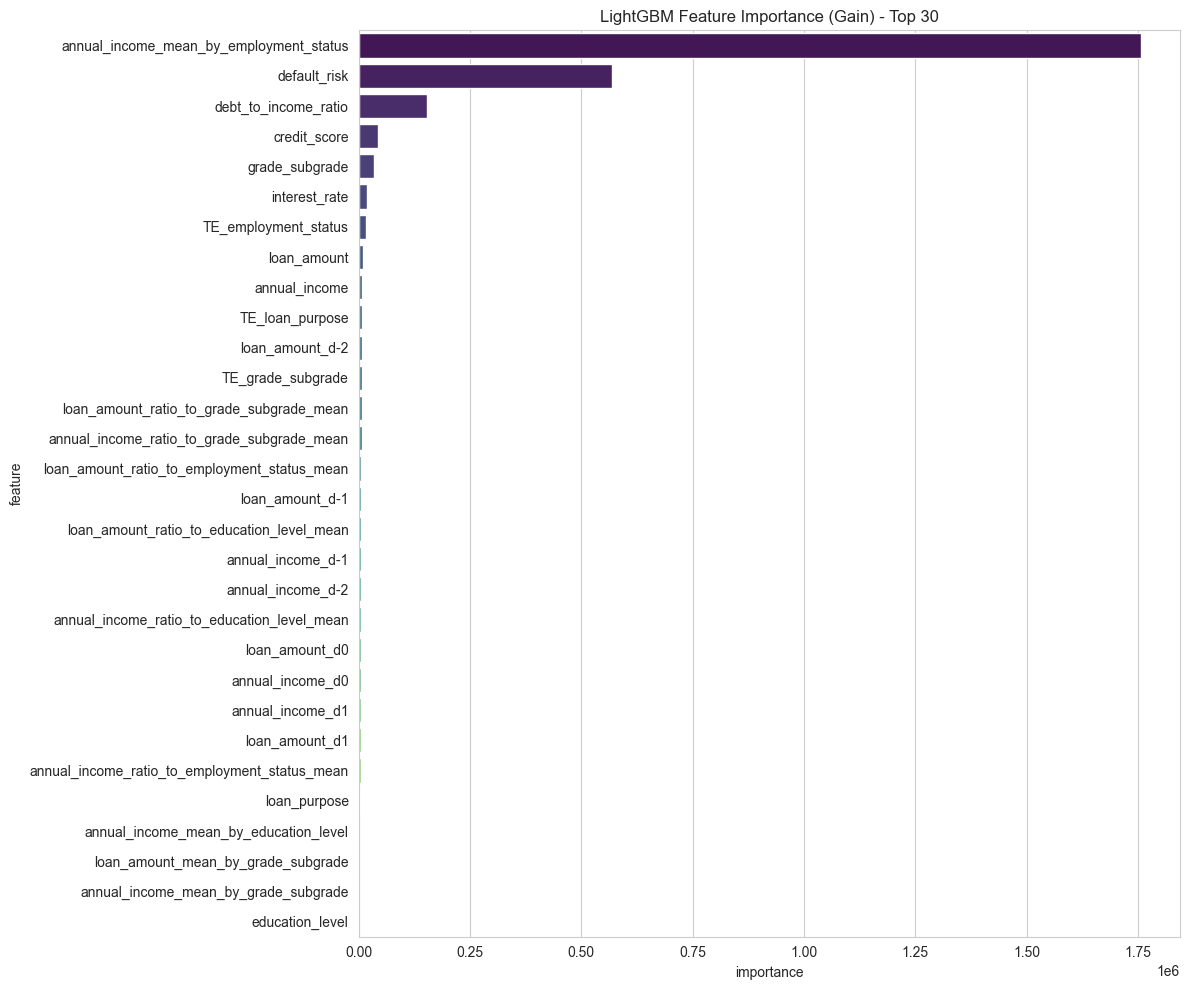

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import TargetEncoder
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import gc

TARGET = 'loan_paid_back'
NUMS = ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']
CATS = ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']

train = pd.read_csv('../train.csv', index_col ='id')
test = pd.read_csv('../test.csv', index_col ='id')

feature_importances = []

# Cechy na podstawie wiedzy domenowej
## wagi dobrane prawdopodobnie na czute (potencjalnie do optymalizacji)
train['default_risk'] = (train['debt_to_income_ratio'] * 0.4 +
                         (850 - train['credit_score']) / 850 * 0.35 +
                         train['interest_rate'] / 100 * 0.25)

test['default_risk'] = (test['debt_to_income_ratio'] * 0.40 +
                        (850 - test['credit_score']) / 850 * 0.35 +
                        test['interest_rate'] / 100 * 0.25)

# Trick z modulo
for c in ['annual_income', 'loan_amount']:
    for k in range(-2, 2):
        n = f'{c}_d{k}'
        train[n] = ((train[c] * 10**k) % 10).fillna(-1).astype("int8")
        test[n] = ((test[c] * 10**k) % 10).fillna(-1).astype("int8")

# Agregacje Grupowe
AGG_COLS = ['annual_income', 'loan_amount']
GROUP_COLS = ['education_level', 'grade_subgrade', 'employment_status']

for group_col in GROUP_COLS:
    for agg_col in AGG_COLS:
        combined_df = pd.concat([train[[group_col, agg_col]], test[[group_col, agg_col]]])
        group_mean = combined_df.groupby(group_col)[agg_col].mean()

        new_col_name = f'{agg_col}_mean_by_{group_col}'
        train[new_col_name] = train[group_col].map(group_mean).astype('float32')
        test[new_col_name] = test[group_col].map(group_mean).astype('float32')

        ratio_col_name = f'{agg_col}_ratio_to_{group_col}_mean'
        train[ratio_col_name] = (train[agg_col] / train[new_col_name]).astype('float32')
        test[ratio_col_name] = (test[agg_col] / test[new_col_name]).astype('float32')

# Specyficzny encoding pod LightGbm (nie jestem przekonany czy to ma sens, ale można zobaczyć)
train['grade_subgrade_d1'] = train['grade_subgrade'].apply(lambda x: x[1] if pd.notnull(x) else '-1')
test['grade_subgrade_d1'] = test['grade_subgrade'].apply(lambda x: x[1] if pd.notnull(x) else '-1')
CATS.append('grade_subgrade_d1')

for cat in CATS:
    train[cat] = train[cat].astype('category')
    test[cat] = test[cat].astype('category')

FEATURES = [col for col in train.columns if col != TARGET]
TE_COLS = ['employment_status', 'loan_purpose', 'grade_subgrade']

skf = StratifiedKFold(n_splits = 5, random_state = 42, shuffle  = True)
oof_preds = np.zeros(len(train))
test_preds = np.zeros(len(test))

lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 6,
    'random_state': 42,
    'n_estimators': 2000,
    'verbose' : -1,
    'n_jobs': -1
}

for fold, (train_idx, val_idx) in enumerate(skf.split(train, train[TARGET])):
    X_train, y_train = train.iloc[train_idx][FEATURES].copy(), train.iloc[train_idx][TARGET]
    X_val, y_val = train.iloc[val_idx][FEATURES].copy(), train.iloc[val_idx][TARGET]
    X_test_fold = test[FEATURES].copy()

    for col in TE_COLS:
        encoder = TargetEncoder(cv=5, random_state=42)
        new_col = f'TE_{col}'
        X_train[new_col] = encoder.fit_transform(X_train[[col]], y_train)
        X_val[new_col] = encoder.transform(X_val[[col]])
        X_test_fold[new_col] = encoder.transform(X_test_fold[[col]])

    current_features = X_train.columns.tolist()

    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
    )

    fold_importance = pd.DataFrame({
        'feature': current_features,
        'importance': model.booster_.feature_importance(importance_type='gain'),
        'fold': fold + 1
    })
    feature_importances.append(fold_importance)

    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    test_preds += model.predict_proba(X_test_fold[current_features])[:, 1] / skf.n_splits

    fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
    print(f"Fold {fold + 1} AUC: {fold_auc:.5f}")

    del X_train, y_train, X_val, y_val, X_test_fold, model, current_features
    gc.collect()

cv_auc = roc_auc_score(train[TARGET], oof_preds)
print(f"\\nOverall CV AUC: {cv_auc:.5f}")

importance_df = pd.concat(feature_importances, axis=0)
mean_importance = importance_df.groupby('feature')['importance'].mean().sort_values(ascending=False).reset_index()

print("\n--- Top 20 Most Important Features ---")
print(mean_importance.head(20))

print("\n--- Bottom 15 Least Important Features (Candidates for removal) ---")
print(mean_importance.tail(15))

plt.figure(figsize=(12, 10))
sns.barplot(
    x='importance',
    y='feature',
    data=mean_importance.head(30),
    palette='viridis'
)
plt.title('LightGBM Feature Importance (Gain) - Top 30')
plt.tight_layout()
plt.show()

pd.DataFrame({'id': train.index, 'lgbm_oof': oof_preds}).to_csv('../lgbm_baseline_oof.csv', index=False)

In [4]:
from src.log_and_run_lgb_experiment import *
lgbm_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 6,
    'random_state': 42,
    'n_estimators': 2000,
    'verbose': -1,
    'n_jobs': -1
}

all_generated_features = [c for c in train.columns if c != 'loan_paid_back']

features_to_drop = [
    'grade_subgrade_d1', 'employment_status', 'loan_purpose', 'TE_grade_subgrade',
    'loan_amount_mean_by_employment_status', 'marital_status', 'gender',
    'loan_amount_mean_by_education_level', 'education_level',
    'annual_income_mean_by_grade_subgrade', 'loan_amount_mean_by_grade_subgrade',
    'annual_income_mean_by_education_level'
]

pruned_features = [f for f in all_generated_features if f not in features_to_drop]

cv_auc_pruned, oof_pruned = run_lgb_experiment(
    train_df=train,
    features_list=pruned_features,
    model_params=lgbm_params,
    experiment_name="lgbm_003_pruned_features"
)


Running Experiment: lgbm_003_pruned_features
Features count: 22
--> Logged lgbm_003_pruned_features with AUC: 0.92198


In [5]:
def prepare_feature_space(train_df, test_df, orig_df):
    print("Building aligned feature space...")

    def apply_base_fe(df):
        res = df.copy()

        res['default_risk'] = (res['debt_to_income_ratio'] * 0.40 +
                              (850 - res['credit_score']) / 850 * 0.35 +
                              res['interest_rate'] / 100 * 0.25)

        for c in ['annual_income', 'loan_amount']:
            for k in range(-2, 2):
                n = f'{c}_d{k}'
                res[n] = ((res[c] * 10**k) % 10).fillna(-1).astype("int8")

        return res

    train_feat = apply_base_fe(train_df)
    test_feat = apply_base_fe(test_df)
    orig_feat = apply_base_fe(orig_df)

    inc_mean_by_emp = orig_feat.groupby('employment_status')['annual_income'].mean()

    train_feat['annual_income_mean_by_employment_status'] = train_feat['employment_status'].map(inc_mean_by_emp).astype('float32')
    test_feat['annual_income_mean_by_employment_status'] = test_feat['employment_status'].map(inc_mean_by_emp).astype('float32')
    orig_feat['annual_income_mean_by_employment_status'] = orig_feat['employment_status'].map(inc_mean_by_emp).astype('float32')

    # Target Encoding (Fitted on orig to avoid leaking synthetic target)
    for col in ['employment_status', 'loan_purpose']:
        te = TargetEncoder(cv=5, random_state=42)
        te_name = f'TE_{col}'

        orig_feat[te_name] = te.fit_transform(orig_feat[[col]], orig_feat['loan_paid_back']).flatten()
        train_feat[te_name] = te.transform(train_feat[[col]]).flatten()
        test_feat[te_name] = te.transform(test_feat[[col]]).flatten()

    # Handle remaining categorical column natively
    train_feat['grade_subgrade'] = train_feat['grade_subgrade'].astype('category')
    test_feat['grade_subgrade'] = test_feat['grade_subgrade'].astype('category')
    orig_feat['grade_subgrade'] = orig_feat['grade_subgrade'].astype('category')

    # Drop identified noise / weak features
    cols_to_drop = [
        'employment_status', 'loan_purpose', 'marital_status', 'gender', 'education_level'
    ]

    train_feat = train_feat.drop(columns=cols_to_drop)
    test_feat = test_feat.drop(columns=cols_to_drop)
    orig_feat = orig_feat.drop(columns=cols_to_drop)

    print(f"Final feature count: {train_feat.shape[1] - 1}") # -1 for target
    return train_feat, test_feat, orig_feat

# Użycie funkcji przed uruchomieniem Boosting Over Residuals:
# train_df, test_df, orig_df = prepare_feature_space(train, test, orig)
# pruned_features = [c for c in train_df.columns if c != 'loan_paid_back']

In [8]:
from scipy.special import logit
from scipy.special import expit
from sklearn.model_selection import train_test_split

train = pd.read_csv('../train.csv')
test = pd.read_csv('../test.csv')
orig = pd.read_csv('../loan_dataset_20000.csv')

train_df, test_df, orig_df = prepare_feature_space(train, test, orig)
pruned_features = [c for c in train_df.columns if c not in ['loan_paid_back', 'id']]

print("--- STAGE 1: Training on Original Dataset ---")
base_model_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 6,
    'random_state': 42,
    'n_estimators': 1500,
    'verbose': -1,
    'n_jobs': -1
}

X_orig_train, X_orig_val, y_orig_train, y_orig_val = train_test_split(
    orig_df[pruned_features], orig_df['loan_paid_back'],
    test_size=0.2, random_state=42, stratify=orig_df['loan_paid_back']
)

base_model = lgb.LGBMClassifier(**base_model_params)
base_model.fit(
    X_orig_train, y_orig_train,
    eval_set=[(X_orig_val, y_orig_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

clip_threshold = 1e-3
train_base_preds = base_model.predict_proba(train_df[pruned_features])[:, 1]
test_base_preds = base_model.predict_proba(test_df[pruned_features])[:, 1]

train_init_score = logit(np.clip(train_base_preds, clip_threshold, 1 - clip_threshold))
test_init_score = logit(np.clip(test_base_preds, clip_threshold, 1 - clip_threshold))

del base_model, X_orig_train, X_orig_val, y_orig_train, y_orig_val
gc.collect()

print("\n--- STAGE 2: Boosting Over Residuals (CV on Synthetic Data) ---")

def run_residual_experiment(train_df, features_list, model_params, init_scores_train, init_scores_test, test_df, experiment_name):
    skf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
    oof_predictions = np.zeros(len(train_df))
    test_predictions = np.zeros(len(test_df))

    for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, train_df['loan_paid_back'])):
        X_train = train_df.iloc[train_idx][features_list]
        y_train = train_df.iloc[train_idx]['loan_paid_back']
        # Extract corresponding init_scores
        init_train = init_scores_train[train_idx]

        X_val = train_df.iloc[val_idx][features_list]
        y_val = train_df.iloc[val_idx]['loan_paid_back']
        init_val = init_scores_train[val_idx]

        model = lgb.LGBMClassifier(**model_params)

        # Fit with init_score
        model.fit(
            X_train, y_train,
            init_score=init_train,
            eval_set=[(X_val, y_val)],
            eval_init_score=[init_val],
            callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
        )

        val_raw_preds = model.booster_.predict(X_val, raw_score=True)
        test_raw_preds = model.booster_.predict(test_df[features_list], raw_score=True)

        oof_predictions[val_idx] = expit(init_val + val_raw_preds)
        test_predictions += expit(init_scores_test + test_raw_preds) / skf.n_splits

        del X_train, y_train, X_val, y_val, model
        gc.collect()

    cv_score = roc_auc_score(train_df['loan_paid_back'], oof_predictions)
    print(f"Residual CV AUC: {cv_score:.5f}")

    # Save predictions
    pd.DataFrame({'id': train_df.index, 'oof_pred': oof_predictions}).to_csv(f"oof_{experiment_name}.csv", index=False)
    pd.DataFrame({'id': test_df.index, 'loan_paid_back': test_predictions}).to_csv(f"sub_{experiment_name}.csv", index=False)

    return cv_score

residual_auc = run_residual_experiment(
    train_df=train_df,
    features_list=pruned_features,
    model_params=base_model_params,
    init_scores_train=train_init_score,
    init_scores_test=test_init_score,
    test_df=test_df,
    experiment_name="lgbm_004_residuals"
)

Building aligned feature space...
Final feature count: 19
--- STAGE 1: Training on Original Dataset ---

--- STAGE 2: Boosting Over Residuals (CV on Synthetic Data) ---
Residual CV AUC: 0.92125


# Bez szpontu z modulo tylko wstrzykiwanie oryginalnych danych z dodaniem flagi is_generated

In [13]:
train = pd.read_csv('../train.csv')
test = pd.read_csv('../test.csv')
orig = pd.read_csv('../loan_dataset_20000.csv')


train_df, test_df, orig_df = prepare_feature_space(train, test, orig)
pruned_features = [c for c in train_df.columns if c not in ['loan_paid_back', 'id']]

train_df['is_generated'] = 1
test_df['is_generated'] = 1
orig_df['is_generated'] = 0

current_features = pruned_features + ['is_generated']

base_model_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 6,
    'random_state': 42,
    'n_estimators': 1500,
    'verbose': -1,
    'n_jobs': -1
}

def run_concatenated_experiment(train_df, orig_df, test_df, features_list, model_params, experiment_name):
    print(f"\nRunning Experiment: {experiment_name}")

    skf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
    oof_predictions = np.zeros(len(train_df))
    test_predictions = np.zeros(len(test_df))

    # Pre-extract target column
    target_col = 'loan_paid_back'
    orig_X = orig_df[features_list]
    orig_y = orig_df[target_col]

    for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, train_df[target_col])):
        # Extract synthetic folds
        X_train_synth = train_df.iloc[train_idx][features_list]
        y_train_synth = train_df.iloc[train_idx][target_col]

        X_val = train_df.iloc[val_idx][features_list]
        y_val = train_df.iloc[val_idx][target_col]

        # Concat original data ONLY to the training set
        X_train = pd.concat([X_train_synth, orig_X], axis=0).reset_index(drop=True)
        y_train = pd.concat([y_train_synth, orig_y], axis=0).reset_index(drop=True)

        model = lgb.LGBMClassifier(**model_params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
        )

        oof_predictions[val_idx] = model.predict_proba(X_val)[:, 1]
        test_predictions += model.predict_proba(test_df[features_list])[:, 1] / skf.n_splits

        del X_train_synth, y_train_synth, X_train, y_train, X_val, y_val, model
        gc.collect()

    cv_score = roc_auc_score(train_df[target_col], oof_predictions)
    print(f"Concatenated CV AUC: {cv_score:.5f}")

    pd.DataFrame({'id': train_df.index, 'oof_pred': oof_predictions}).to_csv(f"oof_{experiment_name}.csv", index=False)
    pd.DataFrame({'id': test_df.index, 'loan_paid_back': test_predictions}).to_csv(f"sub_{experiment_name}.csv", index=False)

    return cv_score, oof_predictions

concat_auc, concat_oof = run_concatenated_experiment(
    train_df=train_df,
    orig_df=orig_df,
    test_df=test_df,
    features_list=current_features,
    model_params=base_model_params, # use the optimal LGBM parameters here
    experiment_name="lgbm_005_concatenated"
)

Building aligned feature space...
Final feature count: 19

Running Experiment: lgbm_005_concatenated
Concatenated CV AUC: 0.92198


In [10]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import TargetEncoder
import gc
import itertools

# 1. Load FRESH data
train = pd.read_csv('../train.csv', index_col='id')
test = pd.read_csv('../test.csv', index_col='id')
orig = pd.read_csv('../loan_dataset_20000.csv')

TARGET = 'loan_paid_back'

lgbm_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.01,
    'n_estimators': 7500,
    'max_depth': 4,
    'subsample': 0.5,
    'colsample_bytree': 0.2,
    'reg_alpha': 10.0,
    'reg_lambda': 15.0,
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1
}

def build_all_features(train_df, test_df, orig_df):
    print("Building unified feature space with deep digit extraction...")

    combined = pd.concat([
        train_df.drop(columns=[TARGET], errors='ignore'),
        test_df
    ])

    # Domain Knowledge
    combined['default_risk'] = (combined['debt_to_income_ratio'] * 0.40 +
                               (850 - combined['credit_score']) / 850 * 0.35 +
                               combined['interest_rate'] / 100 * 0.25)

    # Modulo
    for c in ['annual_income', 'loan_amount']:
        for k in range(-2, 2):
            n = f'{c}_d{k}'
            combined[n] = ((combined[c] * 10**k) % 10).fillna(-1).astype("int8")

    #  Extreme Binning
    print("Applying binning...")
    combined['loan_amount_qcut'] = pd.qcut(combined['loan_amount'], q=10000, duplicates='drop').astype(str)
    combined['annual_income_qcut'] = pd.qcut(combined['annual_income'], q=10000, duplicates='drop').astype(str)
    combined['loan_amount_cut'] = pd.cut(combined['loan_amount'], bins=10000).astype(str)
    combined['annual_income_cut'] = pd.cut(combined['annual_income'], bins=10000).astype(str)

    # Deep Digit Extraction
    print("Extracting digits and creating combinations...")
    digits_df = pd.DataFrame(index=combined.index)
    float_cols = ['annual_income', 'debt_to_income_ratio', 'loan_amount', 'interest_rate']

    for col in float_cols:
        splitted = combined[col].astype(str).str.split(".", expand=True)
        non_decimal = splitted[0]
        decimal = splitted[1].fillna('0')

        max_len_non_dec = non_decimal.str.len().max()
        max_len_dec = decimal.str.len().max()

        non_dec_padded = non_decimal.str.rjust(max_len_non_dec, '0')
        dec_padded = decimal.str.ljust(max_len_dec, '0')

        for i in range(max_len_non_dec):
            digits_df[f"{col}_int_digit_{i}"] = non_dec_padded.str[i]
        for i in range(max_len_dec):
            digits_df[f"{col}_dec_digit_{i}"] = dec_padded.str[i]

    # Add digit combinations for interest_rate
    ir_cols = [c for c in digits_df.columns if "interest_rate" in c]
    for cols in itertools.combinations(ir_cols, 2):
        comb_name = f"{cols[0]}_{cols[1]}_comb"
        digits_df[comb_name] = digits_df[cols[0]].astype(str) + "_" + digits_df[cols[1]].astype(str)

    combined = pd.concat([combined, digits_df], axis=1)

    #Density Ratios
    print("Calculating count ratios...")
    high_card_cols = ['employment_status', 'loan_purpose', 'grade_subgrade']
    count_ratios = {}

    for col in high_card_cols:
        synth_counts = combined.groupby(col, dropna=False).transform('size')
        orig_counts_map = orig_df.groupby(col, dropna=False).size()
        orig_counts = combined[col].map(orig_counts_map).fillna(1)
        count_ratios[f'{col}_count_ratio'] = synth_counts / orig_counts

    ratios_df = pd.DataFrame(count_ratios, index=combined.index)
    combined = pd.concat([combined, ratios_df], axis=1)

    # Split back
    X_train_full = combined.iloc[:len(train_df)].copy()
    X_test_full = combined.iloc[len(train_df):].copy()

    # Define all columns for Target Encoding
    te_columns = high_card_cols + ['loan_amount_qcut', 'annual_income_qcut', 'loan_amount_cut', 'annual_income_cut'] + list(digits_df.columns)

    # Map Original TE for base categorical features
    print("Mapping original TE...")
    orig_te_mapped_train = pd.DataFrame(index=X_train_full.index)
    orig_te_mapped_test = pd.DataFrame(index=X_test_full.index)

    for col in high_card_cols:
        orig_mean = orig_df.groupby(col)[TARGET].mean()
        orig_te_mapped_train[f'TE_orig_{col}'] = X_train_full[col].map(orig_mean).astype('float32')
        orig_te_mapped_test[f'TE_orig_{col}'] = X_test_full[col].map(orig_mean).astype('float32')

    X_train_full = pd.concat([X_train_full, orig_te_mapped_train], axis=1)
    X_test_full = pd.concat([X_test_full, orig_te_mapped_test], axis=1)

    # Clean up standard text columns
    cols_to_drop = ['gender', 'marital_status', 'education_level']
    X_train_full = X_train_full.drop(columns=cols_to_drop)
    X_test_full = X_test_full.drop(columns=cols_to_drop)

    for c in te_columns:
        X_train_full[c] = X_train_full[c].astype('category')
        X_test_full[c] = X_test_full[c].astype('category')

    return X_train_full, X_test_full, train_df[TARGET], te_columns

# Run FE
X_train_adv, X_test_adv, y_train_adv, columns_to_te = build_all_features(train, test, orig)

# 4. CV Loop
print("Starting CV loop with row-wise TE aggregations...")
skf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
oof_preds = np.zeros(len(X_train_adv))
test_preds = np.zeros(len(X_test_adv))

feature_importances = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_adv, y_train_adv)):

    print(f"fold {fold}")

    X_tr = X_train_adv.iloc[train_idx].copy()
    y_tr = y_train_adv.iloc[train_idx]
    X_va = X_train_adv.iloc[val_idx].copy()
    y_va = y_train_adv.iloc[val_idx]
    X_te = X_test_adv.copy()

    # Apply Target Encoding STRICTLY inside CV
    encoder = TargetEncoder(cv=5, random_state=42, smooth=10.0)

    X_tr_te = encoder.fit_transform(X_tr[columns_to_te], y_tr)
    X_va_te = encoder.transform(X_va[columns_to_te])
    X_te_te = encoder.transform(X_te[columns_to_te])

    # Calculate statistics across the TE columns for each row
    X_tr['TE_row_mean'] = np.mean(X_tr_te, axis=1)
    X_tr['TE_row_std'] = np.std(X_tr_te, axis=1)
    X_tr['TE_row_max'] = np.max(X_tr_te, axis=1)
    X_tr['TE_row_min'] = np.min(X_tr_te, axis=1)

    X_va['TE_row_mean'] = np.mean(X_va_te, axis=1)
    X_va['TE_row_std'] = np.std(X_va_te, axis=1)
    X_va['TE_row_max'] = np.max(X_va_te, axis=1)
    X_va['TE_row_min'] = np.min(X_va_te, axis=1)

    X_te['TE_row_mean'] = np.mean(X_te_te, axis=1)
    X_te['TE_row_std'] = np.std(X_te_te, axis=1)
    X_te['TE_row_max'] = np.max(X_te_te, axis=1)
    X_te['TE_row_min'] = np.min(X_te_te, axis=1)

    # Replace categorical columns with their TE versions
    X_tr = X_tr.drop(columns=columns_to_te).assign(**{col: X_tr_te[:, i] for i, col in enumerate(columns_to_te)})
    X_va = X_va.drop(columns=columns_to_te).assign(**{col: X_va_te[:, i] for i, col in enumerate(columns_to_te)})
    X_te = X_te.drop(columns=columns_to_te).assign(**{col: X_te_te[:, i] for i, col in enumerate(columns_to_te)})

    model = lgb.LGBMClassifier(**lgbm_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(stopping_rounds=200, verbose=False),
                   lgb.log_evaluation(1000)]
    )

    fold_importance = pd.DataFrame({
        'feature': X_tr.columns,
        'importance': model.booster_.feature_importance(importance_type='gain'),
        'fold': fold + 1
    })
    feature_importances.append(fold_importance)

    oof_preds[val_idx] = model.predict_proba(X_va)[:, 1]
    test_preds += model.predict_proba(X_te)[:, 1] / skf.n_splits

    del X_tr, y_tr, X_va, y_va, X_te, model
    gc.collect()

cv_auc = roc_auc_score(y_train_adv, oof_preds)
print(f"\nAdvanced FE CV AUC: {cv_auc:.5f}")

importance_df = pd.concat(feature_importances, axis=0)
mean_importance = importance_df.groupby('feature')['importance'].mean().sort_values(ascending=False).reset_index()

print("\n--- Top 30 Features ---")
print(mean_importance.head(30))

print("\n--- Bottom 30 Features (Candidates for removal) ---")
print(mean_importance.tail(30))

Building unified feature space with deep digit extraction...
Applying binning...
Extracting digits and creating combinations...
Calculating count ratios...
Mapping original TE...
Starting CV loop with row-wise TE aggregations...
fold 0
[1000]	valid_0's auc: 0.919406
[2000]	valid_0's auc: 0.921376
[3000]	valid_0's auc: 0.922327
[4000]	valid_0's auc: 0.922944
[5000]	valid_0's auc: 0.923405
[6000]	valid_0's auc: 0.923785
[7000]	valid_0's auc: 0.924116
fold 1
[1000]	valid_0's auc: 0.918843
[2000]	valid_0's auc: 0.921438
[3000]	valid_0's auc: 0.922699
[4000]	valid_0's auc: 0.923569
[5000]	valid_0's auc: 0.92419
[6000]	valid_0's auc: 0.924703
[7000]	valid_0's auc: 0.924977
fold 2
[1000]	valid_0's auc: 0.91738
[2000]	valid_0's auc: 0.919373
[3000]	valid_0's auc: 0.920357
[4000]	valid_0's auc: 0.921084
[5000]	valid_0's auc: 0.921592
[6000]	valid_0's auc: 0.922052
[7000]	valid_0's auc: 0.922386
fold 3
[1000]	valid_0's auc: 0.917734
[2000]	valid_0's auc: 0.91982
[3000]	valid_0's auc: 0.920678
[4

### After Pruning

In [11]:
X_train_adv, X_test_adv, y_train_adv, columns_to_te = build_all_features(train, test, orig)

features_to_drop = [
    # Stare modulo
    'annual_income_d-2', 'annual_income_d-1', 'annual_income_d0', 'annual_income_d1',
    'loan_amount_d-2', 'loan_amount_d-1', 'loan_amount_d0', 'loan_amount_d1',
    # Najsłabsze cyfry
    'debt_to_income_ratio_int_digit_0', 'loan_amount_dec_digit_2', 'annual_income_dec_digit_3',
    'annual_income_int_digit_0', 'annual_income_dec_digit_2', 'loan_purpose_count_ratio',
    'debt_to_income_ratio_dec_digit_4', 'loan_amount_dec_digit_3', 'interest_rate_dec_digit_2',
    'loan_amount_int_digit_0', 'loan_amount_dec_digit_0', 'loan_amount_int_digit_3',
    'annual_income_dec_digit_0', 'debt_to_income_ratio_dec_digit_3', 'interest_rate_int_digit_0',
    'annual_income_int_digit_4', 'interest_rate_dec_digit_1', 'annual_income_dec_digit_1'
]

X_train_adv = X_train_adv.drop(columns=features_to_drop, errors='ignore')
X_test_adv = X_test_adv.drop(columns=features_to_drop, errors='ignore')

columns_to_te = [c for c in columns_to_te if c not in features_to_drop]

print(f"Features after pruning: {X_train_adv.shape[1]}")

print("Starting CV loop with row-wise TE aggregations...")
skf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
oof_preds = np.zeros(len(X_train_adv))
test_preds = np.zeros(len(X_test_adv))

feature_importances = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_adv, y_train_adv)):

    print(f"fold {fold}")

    X_tr = X_train_adv.iloc[train_idx].copy()
    y_tr = y_train_adv.iloc[train_idx]
    X_va = X_train_adv.iloc[val_idx].copy()
    y_va = y_train_adv.iloc[val_idx]
    X_te = X_test_adv.copy()

    # Apply Target Encoding STRICTLY inside CV
    encoder = TargetEncoder(cv=5, random_state=42, smooth=10.0)

    X_tr_te = encoder.fit_transform(X_tr[columns_to_te], y_tr)
    X_va_te = encoder.transform(X_va[columns_to_te])
    X_te_te = encoder.transform(X_te[columns_to_te])

    # Calculate statistics across the TE columns for each row
    X_tr['TE_row_mean'] = np.mean(X_tr_te, axis=1)
    X_tr['TE_row_std'] = np.std(X_tr_te, axis=1)
    X_tr['TE_row_max'] = np.max(X_tr_te, axis=1)
    X_tr['TE_row_min'] = np.min(X_tr_te, axis=1)

    X_va['TE_row_mean'] = np.mean(X_va_te, axis=1)
    X_va['TE_row_std'] = np.std(X_va_te, axis=1)
    X_va['TE_row_max'] = np.max(X_va_te, axis=1)
    X_va['TE_row_min'] = np.min(X_va_te, axis=1)

    X_te['TE_row_mean'] = np.mean(X_te_te, axis=1)
    X_te['TE_row_std'] = np.std(X_te_te, axis=1)
    X_te['TE_row_max'] = np.max(X_te_te, axis=1)
    X_te['TE_row_min'] = np.min(X_te_te, axis=1)

    # Replace categorical columns with their TE versions
    X_tr = X_tr.drop(columns=columns_to_te).assign(**{col: X_tr_te[:, i] for i, col in enumerate(columns_to_te)})
    X_va = X_va.drop(columns=columns_to_te).assign(**{col: X_va_te[:, i] for i, col in enumerate(columns_to_te)})
    X_te = X_te.drop(columns=columns_to_te).assign(**{col: X_te_te[:, i] for i, col in enumerate(columns_to_te)})

    model = lgb.LGBMClassifier(**lgbm_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(stopping_rounds=200, verbose=False),
                   lgb.log_evaluation(1000)]
    )

    fold_importance = pd.DataFrame({
        'feature': X_tr.columns,
        'importance': model.booster_.feature_importance(importance_type='gain'),
        'fold': fold + 1
    })
    feature_importances.append(fold_importance)

    oof_preds[val_idx] = model.predict_proba(X_va)[:, 1]
    test_preds += model.predict_proba(X_te)[:, 1] / skf.n_splits

    del X_tr, y_tr, X_va, y_va, X_te, model
    gc.collect()

cv_auc = roc_auc_score(y_train_adv, oof_preds)
print(f"\nAdvanced FE CV AUC: {cv_auc:.5f}")

Building unified feature space with deep digit extraction...
Applying binning...
Extracting digits and creating combinations...
Calculating count ratios...
Mapping original TE...
Features after pruning: 41
Starting CV loop with row-wise TE aggregations...
fold 0
[1000]	valid_0's auc: 0.919934
[2000]	valid_0's auc: 0.922018
[3000]	valid_0's auc: 0.923124
[4000]	valid_0's auc: 0.923873
[5000]	valid_0's auc: 0.924395
[6000]	valid_0's auc: 0.924816
[7000]	valid_0's auc: 0.925159
fold 1
[1000]	valid_0's auc: 0.919172
[2000]	valid_0's auc: 0.921431
[3000]	valid_0's auc: 0.922636
[4000]	valid_0's auc: 0.923423
[5000]	valid_0's auc: 0.923971
[6000]	valid_0's auc: 0.924431
[7000]	valid_0's auc: 0.924835
fold 2
[1000]	valid_0's auc: 0.917953
[2000]	valid_0's auc: 0.920157
[3000]	valid_0's auc: 0.921303
[4000]	valid_0's auc: 0.9222
[5000]	valid_0's auc: 0.922719
[6000]	valid_0's auc: 0.92317
[7000]	valid_0's auc: 0.923571
fold 3
[1000]	valid_0's auc: 0.918334
[2000]	valid_0's auc: 0.920556
[3000]

In [13]:
importance_df = pd.concat(feature_importances, axis=0)
mean_importance = importance_df.groupby('feature')['importance'].mean().sort_values(ascending=False).reset_index()

print("\n--- Top 15 Features ---")
print(mean_importance.head(15))

print("\n--- Bottom 15 Features (Candidates for removal) ---")
print(mean_importance.tail(15))


--- Top 15 Features ---
                             feature    importance
0                         TE_row_std  2.138660e+06
1                         TE_row_min  2.094268e+06
2          TE_orig_employment_status  1.541831e+06
3                  employment_status  1.027660e+06
4               debt_to_income_ratio  9.997988e+05
5                        TE_row_mean  8.992058e+05
6                       default_risk  8.342551e+05
7                         TE_row_max  7.768145e+05
8      employment_status_count_ratio  7.046889e+05
9   debt_to_income_ratio_dec_digit_0  2.716368e+05
10                      credit_score  2.456735e+05
11            TE_orig_grade_subgrade  2.041700e+05
12                    grade_subgrade  1.853022e+05
13        grade_subgrade_count_ratio  8.439521e+04
14  debt_to_income_ratio_dec_digit_1  7.470805e+04

--- Bottom 15 Features (Candidates for removal) ---
                                              feature   importance
30  interest_rate_int_digit_0_interest_

In [1]:
from src.model_utils import LightGBMWrapper, run_universal_cv
from src.lgbm_utils import build_all_lgbm_features, lgbm_te_preprocessor
import pandas as pd


train = pd.read_csv('../train.csv', index_col='id')
test = pd.read_csv('../test.csv', index_col='id')
orig = pd.read_csv('../loan_dataset_20000.csv')

TARGET = 'loan_paid_back'

X_train_adv, X_test_adv, y_train_adv, columns_to_te = build_all_features(train, test, orig)

features_to_drop = [
    'annual_income_d-2', 'annual_income_d-1', 'annual_income_d0', 'annual_income_d1',
    'loan_amount_d-2', 'loan_amount_d-1', 'loan_amount_d0', 'loan_amount_d1',
    'debt_to_income_ratio_int_digit_0', 'loan_amount_dec_digit_2', 'annual_income_dec_digit_3',
    'annual_income_int_digit_0', 'annual_income_dec_digit_2', 'loan_purpose_count_ratio',
    'debt_to_income_ratio_dec_digit_4', 'loan_amount_dec_digit_3', 'interest_rate_dec_digit_2',
    'loan_amount_int_digit_0', 'loan_amount_dec_digit_0', 'loan_amount_int_digit_3',
    'annual_income_dec_digit_0', 'debt_to_income_ratio_dec_digit_3', 'interest_rate_int_digit_0',
    'annual_income_int_digit_4', 'interest_rate_dec_digit_1', 'annual_income_dec_digit_1'
]

X_train_adv = X_train_adv.drop(columns=features_to_drop, errors='ignore')
X_test_adv = X_test_adv.drop(columns=features_to_drop, errors='ignore')
columns_to_te = [c for c in columns_to_te if c not in features_to_drop]

lgbm_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.01,
    'n_estimators': 7500,
    'max_depth': 4,
    'subsample': 0.5,
    'colsample_bytree': 0.2,
    'reg_alpha': 10.0,
    'reg_lambda': 15.0,
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1
}

lgbm_wrapper = LightGBMWrapper(lgbm_params)

oof_lgbm, test_lgbm = run_universal_cv(
    X_train=X_train_adv,
    y_train=y_train_adv,
    X_test=X_test_adv,
    model_wrapper=lgbm_wrapper,
    preprocessor_func=lgbm_te_preprocessor,
    preprocessor_kwargs={'columns_to_te': columns_to_te}
)

Building unified feature space with deep digit extraction...
Extracting digits...
Calculating count ratios...
Mapping original TE...
Starting Universal CV Loop...
Fold: 0
[1000]	valid_0's auc: 0.919529
[2000]	valid_0's auc: 0.92162
[3000]	valid_0's auc: 0.922463
[4000]	valid_0's auc: 0.923026
[5000]	valid_0's auc: 0.923556
[6000]	valid_0's auc: 0.923927
[7000]	valid_0's auc: 0.924238
Fold: 1
[1000]	valid_0's auc: 0.918786
[2000]	valid_0's auc: 0.920932
[3000]	valid_0's auc: 0.921843
[4000]	valid_0's auc: 0.922473
[5000]	valid_0's auc: 0.923049
[6000]	valid_0's auc: 0.923434
[7000]	valid_0's auc: 0.923816
Fold: 2
[1000]	valid_0's auc: 0.91751
[2000]	valid_0's auc: 0.91952
[3000]	valid_0's auc: 0.920453
[4000]	valid_0's auc: 0.921196
[5000]	valid_0's auc: 0.921768
[6000]	valid_0's auc: 0.922129
[7000]	valid_0's auc: 0.922466
Fold: 3
[1000]	valid_0's auc: 0.917802
[2000]	valid_0's auc: 0.919894
[3000]	valid_0's auc: 0.920813
[4000]	valid_0's auc: 0.921449
[5000]	valid_0's auc: 0.92197
[60

### Testing if Logger works

In [1]:
from src.model_utils import LightGBMWrapper, run_universal_cv
from src.lgbm_utils import build_all_lgbm_features, lgbm_te_preprocessor
from src.logger import ExperimentLogger
import pandas as pd

train = pd.read_csv('../train.csv', index_col='id')
test = pd.read_csv('../test.csv', index_col='id')
orig = pd.read_csv('../loan_dataset_20000.csv')

logger = ExperimentLogger()

TARGET = 'loan_paid_back'

X_train, X_test, y_train, columns_to_te = build_all_features(train, test, orig)


lgbm_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.01,
    'n_estimators': 7500,
    'max_depth': 4,
    'subsample': 0.5,
    'colsample_bytree': 0.2,
    'reg_alpha': 10.0,
    'reg_lambda': 15.0,
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1
}

lgbm_wrapper = LightGBMWrapper(lgbm_params)

oof_lgbm, test_lgbm, cv_auc, importances_df = run_universal_cv(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    model_wrapper=lgbm_wrapper,
    preprocessor_func=lgbm_te_preprocessor,
    preprocessor_kwargs={'columns_to_te': columns_to_te}
)


logger.log_experiment(
    exp_name="lgbm_modular_full_features",
    model_name="LightGBM",
    cv_score=cv_auc,
    params=lgbm_params,
    features_list=X_train.columns,
    importances_df=importances_df
)

Building unified feature space with deep digit extraction...
Extracting digits...
Calculating count ratios...
Mapping original TE...
Starting Universal CV Loop...
Fold: 0
[1000]	valid_0's auc: 0.919742
[2000]	valid_0's auc: 0.922041
[3000]	valid_0's auc: 0.923209
[4000]	valid_0's auc: 0.923985
[5000]	valid_0's auc: 0.924571
[6000]	valid_0's auc: 0.925003
[7000]	valid_0's auc: 0.925287
Fold: 1
[1000]	valid_0's auc: 0.918816
[2000]	valid_0's auc: 0.921114
[3000]	valid_0's auc: 0.922085
[4000]	valid_0's auc: 0.922808
[5000]	valid_0's auc: 0.923305
[6000]	valid_0's auc: 0.923632
[7000]	valid_0's auc: 0.924018
Fold: 2
[1000]	valid_0's auc: 0.91786
[2000]	valid_0's auc: 0.920202
[3000]	valid_0's auc: 0.921573
[4000]	valid_0's auc: 0.922326
[5000]	valid_0's auc: 0.922964
[6000]	valid_0's auc: 0.923441
[7000]	valid_0's auc: 0.923742
Fold: 3
[1000]	valid_0's auc: 0.91829
[2000]	valid_0's auc: 0.920921
[3000]	valid_0's auc: 0.922385
[4000]	valid_0's auc: 0.923228
[5000]	valid_0's auc: 0.923818
[

### LightGBM After Pruning

In [2]:
from src.model_utils import LightGBMWrapper, run_universal_cv
from src.lgbm_utils import build_all_lgbm_features, lgbm_te_preprocessor
from src.logger import ExperimentLogger
import pandas as pd

train = pd.read_csv('../train.csv', index_col='id')
test = pd.read_csv('../test.csv', index_col='id')
orig = pd.read_csv('../loan_dataset_20000.csv')

logger = ExperimentLogger()

TARGET = 'loan_paid_back'

X_train, X_test, y_train, columns_to_te = build_all_features(train, test, orig)

importances_df = pd.read_csv('../logs/20260323_144916_lgbm_modular_full_features_importances.csv')

importance_threshold = 4000
features_to_drop = importances_df[importances_df['importance'] < importance_threshold]['feature'].tolist()

print(f"Dropping {len(features_to_drop)} features below threshold {importance_threshold}.")

X_train = X_train.drop(columns=features_to_drop, errors='ignore')
X_test = X_test.drop(columns=features_to_drop, errors='ignore')
columns_to_te = [c for c in columns_to_te if c not in features_to_drop]

lgbm_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.01,
    'n_estimators': 7500,
    'max_depth': 4,
    'subsample': 0.5,
    'colsample_bytree': 0.2,
    'reg_alpha': 10.0,
    'reg_lambda': 15.0,
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1
}

lgbm_wrapper = LightGBMWrapper(lgbm_params)

oof_lgbm, test_lgbm, cv_auc, importances_df = run_universal_cv(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    model_wrapper=lgbm_wrapper,
    preprocessor_func=lgbm_te_preprocessor,
    preprocessor_kwargs={'columns_to_te': columns_to_te}
)

if importances_df is not None:
    actual_features = importances_df['feature'].tolist()
else:
    actual_features = X_train.columns.tolist()

logger.log_experiment(
    exp_name="lgbm_log_binned_with_prunned_features",
    model_name="LightGBM",
    cv_score=cv_auc,
    params=lgbm_params,
    features_list=actual_features,
    importances_df=importances_df
)

Building unified feature space with deep digit extraction...
Extracting digits...
Calculating count ratios...
Mapping original TE...
Dropping 23 features below threshold 4000.
Starting Universal CV Loop...
Fold: 0
[1000]	valid_0's auc: 0.920257
[2000]	valid_0's auc: 0.922164
[3000]	valid_0's auc: 0.923252
[4000]	valid_0's auc: 0.924068
[5000]	valid_0's auc: 0.924594
[6000]	valid_0's auc: 0.925072
[7000]	valid_0's auc: 0.925375
Fold: 1
[1000]	valid_0's auc: 0.919646
[2000]	valid_0's auc: 0.921655
[3000]	valid_0's auc: 0.923043
[4000]	valid_0's auc: 0.923839
[5000]	valid_0's auc: 0.924429
[6000]	valid_0's auc: 0.924875
[7000]	valid_0's auc: 0.925214
Fold: 2
[1000]	valid_0's auc: 0.918398
[2000]	valid_0's auc: 0.920302
[3000]	valid_0's auc: 0.921484
[4000]	valid_0's auc: 0.922261
[5000]	valid_0's auc: 0.922887
[6000]	valid_0's auc: 0.923482
[7000]	valid_0's auc: 0.923861
Fold: 3
[1000]	valid_0's auc: 0.919261
[2000]	valid_0's auc: 0.92134
[3000]	valid_0's auc: 0.922687
[4000]	valid_0's au

### CatBoost test

In [1]:
from src.model_utils import LightGBMWrapper, run_universal_cv, CatBoostWrapper
from src.lgbm_utils import build_all_lgbm_features, lgbm_te_preprocessor
from src.logger import ExperimentLogger
from src.cb_utils import build_all_cb_features
import pandas as pd

train = pd.read_csv('../train.csv', index_col='id')
test = pd.read_csv('../test.csv', index_col='id')
orig = pd.read_csv('../loan_dataset_20000.csv')

logger = ExperimentLogger()

TARGET = 'loan_paid_back'

X_train, X_test, y_train, columns_to_te = build_all_cb_features(train, test, orig)

# importances_df = pd.read_csv('../logs/20260323_185205_catboost_log_binned_all_features_importances.csv')
#
# importance_threshold = 4000
# features_to_drop = importances_df[importances_df['importance'] < importance_threshold]['feature'].tolist()
#
# print(f"Dropping {len(features_to_drop)} features below threshold {importance_threshold}.")
#
# X_train = X_train.drop(columns=features_to_drop, errors='ignore')
# X_test = X_test.drop(columns=features_to_drop, errors='ignore')
# columns_to_te = [c for c in columns_to_te if c not in features_to_drop]

cb_params = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'iterations': 5000,
    'learning_rate': 0.03,
    'depth': 6,
    'l2_leaf_reg': 5.0,
    'random_seed': 42,
    'task_type': 'GPU',
    'early_stopping_rounds': 200,
    'verbose': 500
}

cat_features = X_train.select_dtypes(include=['category', 'object', 'string']).columns.tolist()

cb_wrapper = CatBoostWrapper(cb_params, cat_features=cat_features)

oof_cb, test_cb, cv_auc_cb, importances_cb = run_universal_cv(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    model_wrapper=cb_wrapper,
    preprocessor_func=None
)

logger.log_experiment(
    exp_name="catboost_log_binned_all_features",
    model_name="CatBoost",
    cv_score=cv_auc_cb,
    params=cb_params,
    features_list=X_train.columns.tolist(),
    importances_df=importances_cb
)

Building CatBoost feature space via modular features.py...
Extracting digits...
Calculating count ratios...
Mapping original TE...
Starting Universal CV Loop...
Fold: 0


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9036713	best: 0.9036713 (0)	total: 740ms	remaining: 1h 1m 37s
500:	test: 0.9217063	best: 0.9217063 (499)	total: 1m 56s	remaining: 17m 23s
1000:	test: 0.9232891	best: 0.9232891 (1000)	total: 4m 1s	remaining: 16m 3s
1500:	test: 0.9240364	best: 0.9240367 (1496)	total: 5m 50s	remaining: 13m 36s
2000:	test: 0.9245297	best: 0.9245309 (1995)	total: 7m 41s	remaining: 11m 32s
2500:	test: 0.9247285	best: 0.9247286 (2499)	total: 9m 32s	remaining: 9m 32s
3000:	test: 0.9249370	best: 0.9249375 (2979)	total: 11m 22s	remaining: 7m 34s
3500:	test: 0.9251170	best: 0.9251177 (3493)	total: 13m 12s	remaining: 5m 39s
4000:	test: 0.9252536	best: 0.9252632 (3978)	total: 15m 2s	remaining: 3m 45s
4500:	test: 0.9254475	best: 0.9254477 (4499)	total: 17m	remaining: 1m 53s
4999:	test: 0.9255062	best: 0.9255067 (4997)	total: 18m 58s	remaining: 0us
bestTest = 0.925506711
bestIteration = 4997
Shrink model to first 4998 iterations.
Fold: 1


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9015305	best: 0.9015305 (0)	total: 228ms	remaining: 19m 1s
500:	test: 0.9210445	best: 0.9210445 (500)	total: 1m 58s	remaining: 17m 48s
1000:	test: 0.9228008	best: 0.9228008 (1000)	total: 3m 55s	remaining: 15m 42s
1500:	test: 0.9236625	best: 0.9236625 (1500)	total: 5m 53s	remaining: 13m 44s
2000:	test: 0.9241596	best: 0.9241596 (1998)	total: 7m 52s	remaining: 11m 48s
2500:	test: 0.9244761	best: 0.9244769 (2498)	total: 9m 49s	remaining: 9m 48s
3000:	test: 0.9247430	best: 0.9247437 (2995)	total: 11m 52s	remaining: 7m 54s
3500:	test: 0.9248749	best: 0.9248749 (3500)	total: 13m 56s	remaining: 5m 58s
4000:	test: 0.9250345	best: 0.9250357 (3997)	total: 16m 1s	remaining: 4m
4500:	test: 0.9251837	best: 0.9251857 (4487)	total: 18m 18s	remaining: 2m 1s
4999:	test: 0.9252973	best: 0.9253024 (4925)	total: 20m 29s	remaining: 0us
bestTest = 0.9253024459
bestIteration = 4925
Shrink model to first 4926 iterations.
Fold: 2


...

0:	test: 0.8997292	best: 0.8997292 (0)	total: 225ms	remaining: 18m 45s
500:	test: 0.9198414	best: 0.9198414 (500)	total: 1m 57s	remaining: 17m 33s
1000:	test: 0.9216337	best: 0.9216337 (1000)	total: 3m 56s	remaining: 15m 44s
1500:	test: 0.9225743	best: 0.9225743 (1500)	total: 5m 54s	remaining: 13m 47s
2000:	test: 0.9229829	best: 0.9229829 (2000)	total: 7m 53s	remaining: 11m 50s
2500:	test: 0.9231899	best: 0.9231907 (2494)	total: 10m 13s	remaining: 10m 12s
3000:	test: 0.9234645	best: 0.9234649 (2990)	total: 12m 6s	remaining: 8m 3s
3500:	test: 0.9236036	best: 0.9236036 (3500)	total: 13m 58s	remaining: 5m 59s
4000:	test: 0.9237439	best: 0.9237449 (3983)	total: 16m 6s	remaining: 4m 1s
4500:	test: 0.9238660	best: 0.9238667 (4499)	total: 18m 7s	remaining: 2m
4999:	test: 0.9240214	best: 0.9240229 (4996)	total: 20m 9s	remaining: 0us
bestTest = 0.924022913
bestIteration = 4996
Shrink model to first 4997 iterations.
Fold: 3


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9002416	best: 0.9002416 (0)	total: 411ms	remaining: 34m 13s
500:	test: 0.9209539	best: 0.9209539 (500)	total: 1m 55s	remaining: 17m 14s
1000:	test: 0.9224393	best: 0.9224393 (999)	total: 3m 48s	remaining: 15m 14s
1500:	test: 0.9232235	best: 0.9232237 (1499)	total: 5m 42s	remaining: 13m 19s
2000:	test: 0.9237402	best: 0.9237424 (1993)	total: 7m 35s	remaining: 11m 22s
2500:	test: 0.9240888	best: 0.9240888 (2500)	total: 9m 28s	remaining: 9m 28s
3000:	test: 0.9243416	best: 0.9243416 (3000)	total: 11m 23s	remaining: 7m 35s
3500:	test: 0.9246063	best: 0.9246075 (3497)	total: 13m 14s	remaining: 5m 40s
4000:	test: 0.9247208	best: 0.9247212 (3987)	total: 15m 7s	remaining: 3m 46s
4500:	test: 0.9248055	best: 0.9248060 (4497)	total: 17m 7s	remaining: 1m 53s
4999:	test: 0.9249721	best: 0.9249724 (4998)	total: 19m 5s	remaining: 0us
bestTest = 0.9249723554
bestIteration = 4998
Shrink model to first 4999 iterations.
Fold: 4


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9017244	best: 0.9017244 (0)	total: 386ms	remaining: 32m 11s
500:	test: 0.9205624	best: 0.9205624 (500)	total: 1m 59s	remaining: 17m 57s
1000:	test: 0.9221833	best: 0.9221833 (1000)	total: 3m 55s	remaining: 15m 40s
1500:	test: 0.9229408	best: 0.9229408 (1500)	total: 5m 47s	remaining: 13m 29s
2000:	test: 0.9234194	best: 0.9234194 (1999)	total: 7m 38s	remaining: 11m 27s
2500:	test: 0.9237530	best: 0.9237530 (2500)	total: 9m 29s	remaining: 9m 29s
3000:	test: 0.9239879	best: 0.9239892 (2995)	total: 11m 22s	remaining: 7m 34s
3500:	test: 0.9241793	best: 0.9241793 (3500)	total: 13m 15s	remaining: 5m 40s
4000:	test: 0.9243321	best: 0.9243333 (3993)	total: 15m 10s	remaining: 3m 47s
4500:	test: 0.9244369	best: 0.9244387 (4480)	total: 17m 4s	remaining: 1m 53s
4999:	test: 0.9245384	best: 0.9245408 (4978)	total: 18m 58s	remaining: 0us
bestTest = 0.9245407581
bestIteration = 4978
Shrink model to first 4979 iterations.

CV AUC: 0.92486

[Logger] Successfully logged experiment: 20260323_1852

### CatBoost after Pruning

In [2]:
from src.model_utils import LightGBMWrapper, run_universal_cv, CatBoostWrapper
from src.lgbm_utils import build_all_lgbm_features, lgbm_te_preprocessor
from src.logger import ExperimentLogger
from src.cb_utils import build_all_cb_features
import pandas as pd

train = pd.read_csv('../train.csv', index_col='id')
test = pd.read_csv('../test.csv', index_col='id')
orig = pd.read_csv('../loan_dataset_20000.csv')

logger = ExperimentLogger()

TARGET = 'loan_paid_back'

X_train, X_test, y_train, columns_to_te = build_all_cb_features(train, test, orig)

importances_df = pd.read_csv('../logs/20260323_185205_catboost_log_binned_all_features_importances.csv')

importance_threshold = 0.1
features_to_drop = importances_df[importances_df['importance'] < importance_threshold]['feature'].tolist()

print(f"Dropping {len(features_to_drop)} features below threshold {importance_threshold}.")

X_train = X_train.drop(columns=features_to_drop, errors='ignore')
X_test = X_test.drop(columns=features_to_drop, errors='ignore')
columns_to_te = [c for c in columns_to_te if c not in features_to_drop]

cb_params = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'iterations': 5000,
    'learning_rate': 0.03,
    'depth': 6,
    'l2_leaf_reg': 5.0,
    'random_seed': 42,
    'task_type': 'GPU',
    'early_stopping_rounds': 200,
    'verbose': 500
}

cat_features = X_train.select_dtypes(include=['category', 'object', 'string']).columns.tolist()

cb_wrapper = CatBoostWrapper(cb_params, cat_features=cat_features)

oof_cb, test_cb, cv_auc_cb, importances_cb = run_universal_cv(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    model_wrapper=cb_wrapper,
    preprocessor_func=None
)

logger.log_experiment(
    exp_name="catboost_log_binned_with_pruned_features",
    model_name="CatBoost",
    cv_score=cv_auc_cb,
    params=cb_params,
    features_list=X_train.columns.tolist(),
    importances_df=importances_cb
)

Building CatBoost feature space via modular features.py...
Extracting digits...
Calculating count ratios...
Mapping original TE...
Dropping 16 features below threshold 0.1.
Starting Universal CV Loop...
Fold: 0


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9069241	best: 0.9069241 (0)	total: 399ms	remaining: 33m 16s
500:	test: 0.9218083	best: 0.9218083 (500)	total: 1m 53s	remaining: 17m 3s
1000:	test: 0.9232902	best: 0.9232902 (1000)	total: 3m 50s	remaining: 15m 19s
1500:	test: 0.9239717	best: 0.9239717 (1500)	total: 5m 40s	remaining: 13m 14s
2000:	test: 0.9244279	best: 0.9244300 (1995)	total: 7m 39s	remaining: 11m 29s
2500:	test: 0.9247223	best: 0.9247223 (2500)	total: 9m 38s	remaining: 9m 38s
3000:	test: 0.9249489	best: 0.9249489 (3000)	total: 11m 36s	remaining: 7m 43s
3500:	test: 0.9251161	best: 0.9251161 (3500)	total: 13m 34s	remaining: 5m 48s
4000:	test: 0.9252414	best: 0.9252423 (3989)	total: 15m 28s	remaining: 3m 51s
4500:	test: 0.9253880	best: 0.9253883 (4497)	total: 17m 24s	remaining: 1m 55s
4999:	test: 0.9254538	best: 0.9254578 (4944)	total: 19m 24s	remaining: 0us
bestTest = 0.9254577756
bestIteration = 4944
Shrink model to first 4945 iterations.
Fold: 1


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8985391	best: 0.8985391 (0)	total: 247ms	remaining: 20m 34s
500:	test: 0.9212751	best: 0.9212751 (500)	total: 1m 50s	remaining: 16m 33s
1000:	test: 0.9230216	best: 0.9230216 (1000)	total: 3m 41s	remaining: 14m 43s
1500:	test: 0.9238689	best: 0.9238689 (1500)	total: 5m 30s	remaining: 12m 49s
2000:	test: 0.9243312	best: 0.9243313 (1999)	total: 7m 16s	remaining: 10m 54s
2500:	test: 0.9246662	best: 0.9246662 (2500)	total: 9m 4s	remaining: 9m 3s
3000:	test: 0.9248665	best: 0.9248692 (2983)	total: 10m 51s	remaining: 7m 13s
3500:	test: 0.9250067	best: 0.9250083 (3491)	total: 12m 38s	remaining: 5m 24s
4000:	test: 0.9252028	best: 0.9252051 (3986)	total: 14m 25s	remaining: 3m 36s
4500:	test: 0.9253338	best: 0.9253367 (4480)	total: 16m 17s	remaining: 1m 48s
4999:	test: 0.9254509	best: 0.9254531 (4951)	total: 18m 7s	remaining: 0us
bestTest = 0.9254531264
bestIteration = 4951
Shrink model to first 4952 iterations.
Fold: 2


...

0:	test: 0.9043345	best: 0.9043345 (0)	total: 232ms	remaining: 19m 22s
500:	test: 0.9200060	best: 0.9200060 (500)	total: 2m	remaining: 18m 2s
1000:	test: 0.9217457	best: 0.9217457 (1000)	total: 3m 57s	remaining: 15m 50s
1500:	test: 0.9226197	best: 0.9226198 (1498)	total: 6m 12s	remaining: 14m 28s
2000:	test: 0.9230126	best: 0.9230132 (1997)	total: 8m 28s	remaining: 12m 42s
2500:	test: 0.9232747	best: 0.9232747 (2499)	total: 10m 40s	remaining: 10m 40s
3000:	test: 0.9234751	best: 0.9234751 (3000)	total: 12m 37s	remaining: 8m 24s
3500:	test: 0.9236599	best: 0.9236610 (3499)	total: 14m 30s	remaining: 6m 12s
4000:	test: 0.9237985	best: 0.9237995 (3985)	total: 16m 22s	remaining: 4m 5s
4500:	test: 0.9238991	best: 0.9239009 (4494)	total: 18m 16s	remaining: 2m 1s
4999:	test: 0.9239932	best: 0.9239964 (4983)	total: 20m 4s	remaining: 0us
bestTest = 0.9239963591
bestIteration = 4983
Shrink model to first 4984 iterations.
Fold: 3


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9053538	best: 0.9053538 (0)	total: 224ms	remaining: 18m 40s
500:	test: 0.9209806	best: 0.9209806 (500)	total: 1m 47s	remaining: 16m 7s
1000:	test: 0.9226712	best: 0.9226713 (999)	total: 3m 34s	remaining: 14m 17s
1500:	test: 0.9233974	best: 0.9233974 (1500)	total: 5m 19s	remaining: 12m 25s
2000:	test: 0.9238318	best: 0.9238328 (1996)	total: 7m 5s	remaining: 10m 38s
2500:	test: 0.9241462	best: 0.9241462 (2500)	total: 9m 3s	remaining: 9m 3s
3000:	test: 0.9244196	best: 0.9244204 (2999)	total: 11m 9s	remaining: 7m 25s
3500:	test: 0.9246480	best: 0.9246486 (3498)	total: 13m 18s	remaining: 5m 42s
4000:	test: 0.9247888	best: 0.9247904 (3982)	total: 15m 29s	remaining: 3m 52s
4500:	test: 0.9248583	best: 0.9248591 (4493)	total: 17m 38s	remaining: 1m 57s
4999:	test: 0.9249834	best: 0.9249836 (4998)	total: 19m 51s	remaining: 0us
bestTest = 0.9249836206
bestIteration = 4998
Shrink model to first 4999 iterations.
Fold: 4


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8986275	best: 0.8986275 (0)	total: 246ms	remaining: 20m 28s
500:	test: 0.9205388	best: 0.9205388 (500)	total: 2m 11s	remaining: 19m 41s
1000:	test: 0.9222543	best: 0.9222543 (1000)	total: 4m 16s	remaining: 17m 5s
1500:	test: 0.9229495	best: 0.9229495 (1500)	total: 6m 2s	remaining: 14m 5s
2000:	test: 0.9234480	best: 0.9234480 (2000)	total: 7m 50s	remaining: 11m 44s
2500:	test: 0.9237744	best: 0.9237744 (2500)	total: 9m 44s	remaining: 9m 43s
3000:	test: 0.9240124	best: 0.9240133 (2996)	total: 11m 47s	remaining: 7m 50s
3500:	test: 0.9241775	best: 0.9241787 (3490)	total: 13m 45s	remaining: 5m 53s
4000:	test: 0.9243014	best: 0.9243028 (3962)	total: 15m 48s	remaining: 3m 56s
4500:	test: 0.9244133	best: 0.9244164 (4478)	total: 17m 49s	remaining: 1m 58s
4999:	test: 0.9245088	best: 0.9245121 (4958)	total: 19m 44s	remaining: 0us
bestTest = 0.9245120883
bestIteration = 4958
Shrink model to first 4959 iterations.

CV AUC: 0.92488

[Logger] Successfully logged experiment: 20260323_204739

In [1]:
from src.model_utils import run_universal_cv, XGBoostWrapper
from src.logger import ExperimentLogger
from src.xgb_utils import build_all_xgb_features
import pandas as pd
from src.lgbm_utils import lgbm_te_preprocessor

train = pd.read_csv('../train.csv', index_col='id')
test = pd.read_csv('../test.csv', index_col='id')
orig = pd.read_csv('../loan_dataset_20000.csv')

logger = ExperimentLogger()

TARGET = 'loan_paid_back'

X_train, X_test, y_train, columns_to_te = build_all_xgb_features(train, test, orig)

# importances_df = pd.read_csv('../logs/20260324_151610_xgboost_full_features_importances.csv')
#
# importance_threshold = 0.1
# features_to_drop = importances_df[importances_df['importance'] < importance_threshold]['feature'].tolist()
#
# print(f"Dropping {len(features_to_drop)} features below threshold {importance_threshold}.")
#
# X_train = X_train.drop(columns=features_to_drop, errors='ignore')
# X_test = X_test.drop(columns=features_to_drop, errors='ignore')
# columns_to_te = [c for c in columns_to_te if c not in features_to_drop]

xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'n_estimators': 10000,
    'learning_rate': 0.01,
    'max_depth': 6,
    'subsample': 0.6,
    'colsample_bytree': 0.5,
    'tree_method': 'hist',
    'random_state': 42,
    'early_stopping_rounds': 500,
    'verbose': 1000
}

xgb_wrapper = XGBoostWrapper(xgb_params)

oof_xgb, test_xgb, cv_auc_xgb, importances_xgb = run_universal_cv(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    model_wrapper=xgb_wrapper,
    preprocessor_func=lgbm_te_preprocessor,
    preprocessor_kwargs={'columns_to_te': columns_to_te}
)

logger.log_experiment(
    exp_name="xgboost_10000_estimators_all_features",
    model_name="XGBoost",
    cv_score=cv_auc_xgb,
    params=xgb_params,
    features_list=X_train.columns.tolist(),
    importances_df=importances_xgb
)

Building XGBoost feature space via modular features.py...
Extracting digits...
Calculating count ratios...
Mapping original TE...
Starting Universal CV Loop...
Fold: 0
[0]	validation_0-auc:0.90827
[1000]	validation_0-auc:0.92287
[2000]	validation_0-auc:0.92419
[3000]	validation_0-auc:0.92468
[4000]	validation_0-auc:0.92493
[5000]	validation_0-auc:0.92505
[5578]	validation_0-auc:0.92501
Fold: 1
[0]	validation_0-auc:0.90707
[1000]	validation_0-auc:0.92253
[2000]	validation_0-auc:0.92401
[3000]	validation_0-auc:0.92450
[4000]	validation_0-auc:0.92475
[5000]	validation_0-auc:0.92484
[5114]	validation_0-auc:0.92483
Fold: 2
[0]	validation_0-auc:0.90621
[1000]	validation_0-auc:0.92119
[2000]	validation_0-auc:0.92267
[3000]	validation_0-auc:0.92320
[4000]	validation_0-auc:0.92346
[5000]	validation_0-auc:0.92352
[5379]	validation_0-auc:0.92350
Fold: 3
[0]	validation_0-auc:0.90700
[1000]	validation_0-auc:0.92216
[2000]	validation_0-auc:0.92345
[3000]	validation_0-auc:0.92406
[4000]	validation_0-

### XGB with pseudo-TE

In [1]:
from src.model_utils import run_universal_cv, XGBoostWrapper
from src.logger import ExperimentLogger
from src.xgb_utils import build_all_xgb_features
import pandas as pd
from src.lgbm_utils import lgbm_te_preprocessor

train = pd.read_csv('../train.csv', index_col='id')
test = pd.read_csv('../test.csv', index_col='id')
orig = pd.read_csv('../loan_dataset_20000.csv')

logger = ExperimentLogger()

TARGET = 'loan_paid_back'

X_train, X_test, y_train, columns_to_te = build_all_xgb_features(train, test, orig)

# importances_df = pd.read_csv('../logs/20260324_151610_xgboost_full_features_importances.csv')
#
# importance_threshold = 0.1
# features_to_drop = importances_df[importances_df['importance'] < importance_threshold]['feature'].tolist()
#
# print(f"Dropping {len(features_to_drop)} features below threshold {importance_threshold}.")
#
# X_train = X_train.drop(columns=features_to_drop, errors='ignore')
# X_test = X_test.drop(columns=features_to_drop, errors='ignore')
# columns_to_te = [c for c in columns_to_te if c not in features_to_drop]

xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'n_estimators': 10000,
    'learning_rate': 0.01,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.5,
    'tree_method': 'hist',
    'device': 'cuda',
    'random_state': 42,
    'early_stopping_rounds': 500,
    'verbose': 1000
}

xgb_wrapper = XGBoostWrapper(xgb_params)

oof_xgb, test_xgb, cv_auc_xgb, importances_xgb = run_universal_cv(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    model_wrapper=xgb_wrapper,
    preprocessor_func=lgbm_te_preprocessor,
    preprocessor_kwargs={'columns_to_te': columns_to_te},
    n_splits=20
)

logger.log_experiment(
    exp_name="xgboost_pseudoTE_all_features",
    model_name="XGBoost",
    cv_score=cv_auc_xgb,
    params=xgb_params,
    features_list=X_train.columns.tolist(),
    importances_df=importances_xgb
)

Building XGBoost feature space via modular features.py...
Extracting digits...
Building interactions with cardinality dropout...
Mapping Original TE & Pseudo-TE...
Starting Universal CV Loop...
Fold: 0
[0]	validation_0-auc:0.86502
[1000]	validation_0-auc:0.92366
[2000]	validation_0-auc:0.92510
[3000]	validation_0-auc:0.92562
[4000]	validation_0-auc:0.92574
[4071]	validation_0-auc:0.92575


G:\ML_Projects\DataScienceClub_RekruProject\DSC_PJATK_recruitment_task_2026\.venv\Lib\site-packages\xgboost\core.py:751: UserWarning: [17:25:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Fold: 1
[0]	validation_0-auc:0.86734
[1000]	validation_0-auc:0.92372
[2000]	validation_0-auc:0.92533
[3000]	validation_0-auc:0.92590
[4000]	validation_0-auc:0.92620
[5000]	validation_0-auc:0.92625
[6000]	validation_0-auc:0.92627
[6079]	validation_0-auc:0.92628
Fold: 2
[0]	validation_0-auc:0.86518
[1000]	validation_0-auc:0.92212
[2000]	validation_0-auc:0.92383
[3000]	validation_0-auc:0.92448
[4000]	validation_0-auc:0.92483
[5000]	validation_0-auc:0.92497
[5695]	validation_0-auc:0.92499
Fold: 3
[0]	validation_0-auc:0.86633
[1000]	validation_0-auc:0.92169
[2000]	validation_0-auc:0.92317
[3000]	validation_0-auc:0.92390
[4000]	validation_0-auc:0.92421
[5000]	validation_0-auc:0.92445
[6000]	validation_0-auc:0.92446
[6057]	validation_0-auc:0.92446
Fold: 4
[0]	validation_0-auc:0.86592
[1000]	validation_0-auc:0.92303
[2000]	validation_0-auc:0.92479
[3000]	validation_0-auc:0.92538
[4000]	validation_0-auc:0.92576
[5000]	validation_0-auc:0.92603
[6000]	validation_0-auc:0.92616
[7000]	validation_0-

In [3]:
from src.model_utils import run_universal_cv, XGBoostWrapper
from src.logger import ExperimentLogger
from src.xgb_utils import build_all_xgb_features
import pandas as pd
from src.lgbm_utils import lgbm_te_preprocessor

train = pd.read_csv('../train.csv', index_col='id')
test = pd.read_csv('../test.csv', index_col='id')
orig = pd.read_csv('../loan_dataset_20000.csv')

logger = ExperimentLogger()

TARGET = 'loan_paid_back'

X_train, X_test, y_train, columns_to_te = build_all_xgb_features(train, test, orig)

importances_df = pd.read_csv('../logs/20260324_180251_xgboost_pseudoTE_all_features_importances.csv')

importance_threshold = 0.001
features_to_drop = importances_df[importances_df['importance'] < importance_threshold]['feature'].tolist()

print(f"Dropping {len(features_to_drop)} features below threshold {importance_threshold}.")

X_train = X_train.drop(columns=features_to_drop, errors='ignore')
X_test = X_test.drop(columns=features_to_drop, errors='ignore')
columns_to_te = [c for c in columns_to_te if c not in features_to_drop]

xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'n_estimators': 10000,
    'learning_rate': 0.01,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.5,
    'tree_method': 'hist',
    'device': 'cuda',
    'random_state': 42,
    'early_stopping_rounds': 500,
    'verbose': 1000
}

xgb_wrapper = XGBoostWrapper(xgb_params)

oof_xgb, test_xgb, cv_auc_xgb, importances_xgb = run_universal_cv(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    model_wrapper=xgb_wrapper,
    preprocessor_func=lgbm_te_preprocessor,
    preprocessor_kwargs={'columns_to_te': columns_to_te},
    n_splits=20
)

logger.log_experiment(
    exp_name="xgboost_pseudoTE_all_features",
    model_name="XGBoost",
    cv_score=cv_auc_xgb,
    params=xgb_params,
    features_list=X_train.columns.tolist(),
    importances_df=importances_xgb
)

Building XGBoost feature space via modular features.py...
Extracting digits...
Building interactions with cardinality dropout...
Mapping Original TE & Pseudo-TE...
Dropping 8 features below threshold 0.001.
Starting Universal CV Loop...
Fold: 0
[0]	validation_0-auc:0.86523
[1000]	validation_0-auc:0.92356
[2000]	validation_0-auc:0.92498
[3000]	validation_0-auc:0.92547
[4000]	validation_0-auc:0.92565
[5000]	validation_0-auc:0.92565
[5061]	validation_0-auc:0.92566
Fold: 1
[0]	validation_0-auc:0.86561
[1000]	validation_0-auc:0.92371
[2000]	validation_0-auc:0.92524
[3000]	validation_0-auc:0.92587
[4000]	validation_0-auc:0.92611
[5000]	validation_0-auc:0.92622
[5423]	validation_0-auc:0.92624
Fold: 2
[0]	validation_0-auc:0.86546
[1000]	validation_0-auc:0.92221
[2000]	validation_0-auc:0.92374
[3000]	validation_0-auc:0.92423
[4000]	validation_0-auc:0.92471
[5000]	validation_0-auc:0.92486
[6000]	validation_0-auc:0.92495
[6349]	validation_0-auc:0.92495
Fold: 3
[0]	validation_0-auc:0.86632
[1000]	

### XGB with agressive interactions and psuedo TE

In [1]:
from src.model_utils import run_universal_cv, XGBoostWrapper
from src.logger import ExperimentLogger
from src.xgb_utils import build_all_xgb_features
import pandas as pd
from src.lgbm_utils import lgbm_te_preprocessor

train = pd.read_csv('../train.csv', index_col='id')
test = pd.read_csv('../test.csv', index_col='id')
orig = pd.read_csv('../loan_dataset_20000.csv')

logger = ExperimentLogger()

TARGET = 'loan_paid_back'

X_train, X_test, y_train, columns_to_te = build_all_xgb_features(train, test, orig)

xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'n_estimators': 10000,
    'learning_rate': 0.01,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.5,
    'tree_method': 'hist',
    'device': 'cuda',
    'random_state': 42,
    'early_stopping_rounds': 500,
    'verbose': 1000
}

xgb_wrapper = XGBoostWrapper(xgb_params)

oof_xgb, test_xgb, cv_auc_xgb, importances_xgb = run_universal_cv(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    model_wrapper=xgb_wrapper,
    preprocessor_func=lgbm_te_preprocessor,
    preprocessor_kwargs={'columns_to_te': columns_to_te},
    n_splits=5
)

logger.log_experiment(
    exp_name="xgboost_pseudoTE_all_features",
    model_name="XGBoost",
    cv_score=cv_auc_xgb,
    params=xgb_params,
    features_list=X_train.columns.tolist(),
    importances_df=importances_xgb
)

Building XGBoost feature space via modular features.py...
Extracting digits...
Building aggressive interactions with cardinality dropout...
Mapping Original TE & Pseudo-TE...
Starting Universal CV Loop...
Fold: 0


G:\ML_Projects\DataScienceClub_RekruProject\DSC_PJATK_recruitment_task_2026\src\lgbm_utils.py:121: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_tr = X_tr.drop(columns=columns_to_te).assign(**{col: X_tr_te[:, i] for i, col in enumerate(columns_to_te)})
G:\ML_Projects\DataScienceClub_RekruProject\DSC_PJATK_recruitment_task_2026\src\lgbm_utils.py:122: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_va = X_va.drop(columns=columns_to_te).assign(**{col: X_va_te[:, i] for i, col in enumerate(columns_to_te)})
G:\ML_Projects\DataScien

[0]	validation_0-auc:0.91054
[1000]	validation_0-auc:0.92251
[2000]	validation_0-auc:0.92330
[3000]	validation_0-auc:0.92357
[4000]	validation_0-auc:0.92373
[5000]	validation_0-auc:0.92377
[5472]	validation_0-auc:0.92375


G:\ML_Projects\DataScienceClub_RekruProject\DSC_PJATK_recruitment_task_2026\.venv\Lib\site-packages\xgboost\core.py:751: UserWarning: [21:13:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Fold: 1


...

[0]	validation_0-auc:0.90925
[1000]	validation_0-auc:0.92049
[2000]	validation_0-auc:0.92138
[3000]	validation_0-auc:0.92161
[4000]	validation_0-auc:0.92166
[4959]	validation_0-auc:0.92168
Fold: 3


G:\ML_Projects\DataScienceClub_RekruProject\DSC_PJATK_recruitment_task_2026\src\lgbm_utils.py:121: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_tr = X_tr.drop(columns=columns_to_te).assign(**{col: X_tr_te[:, i] for i, col in enumerate(columns_to_te)})
G:\ML_Projects\DataScienceClub_RekruProject\DSC_PJATK_recruitment_task_2026\src\lgbm_utils.py:122: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_va = X_va.drop(columns=columns_to_te).assign(**{col: X_va_te[:, i] for i, col in enumerate(columns_to_te)})
G:\ML_Projects\DataScien

[0]	validation_0-auc:0.90926
[1000]	validation_0-auc:0.92146
[2000]	validation_0-auc:0.92239
[3000]	validation_0-auc:0.92272
[4000]	validation_0-auc:0.92279
[5000]	validation_0-auc:0.92282
[5479]	validation_0-auc:0.92278
Fold: 4


G:\ML_Projects\DataScienceClub_RekruProject\DSC_PJATK_recruitment_task_2026\src\lgbm_utils.py:121: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_tr = X_tr.drop(columns=columns_to_te).assign(**{col: X_tr_te[:, i] for i, col in enumerate(columns_to_te)})
G:\ML_Projects\DataScienceClub_RekruProject\DSC_PJATK_recruitment_task_2026\src\lgbm_utils.py:122: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_va = X_va.drop(columns=columns_to_te).assign(**{col: X_va_te[:, i] for i, col in enumerate(columns_to_te)})
G:\ML_Projects\DataScien

[0]	validation_0-auc:0.90918
[1000]	validation_0-auc:0.92070
[2000]	validation_0-auc:0.92159
[3000]	validation_0-auc:0.92177
[4000]	validation_0-auc:0.92187
[4390]	validation_0-auc:0.92186

CV AUC: 0.92267

[Logger] Successfully logged experiment: 20260324_215505_xgboost_pseudoTE_all_features
[Logger] CV AUC: 0.92267


### First test pruning (leaving 50 features)

In [1]:
from src.model_utils import run_universal_cv, XGBoostWrapper
from src.logger import ExperimentLogger
from src.xgb_utils import build_all_xgb_features
import pandas as pd
from src.lgbm_utils import lgbm_te_preprocessor

train = pd.read_csv('../train.csv', index_col='id')
test = pd.read_csv('../test.csv', index_col='id')
orig = pd.read_csv('../loan_dataset_20000.csv')

logger = ExperimentLogger()

TARGET = 'loan_paid_back'

X_train, X_test, y_train, columns_to_te = build_all_xgb_features(train, test, orig)

importances_df = pd.read_csv('../logs/20260324_215505_xgboost_pseudoTE_all_features_importances.csv')

importance_threshold = 0.001
features_to_drop = importances_df[importances_df['importance'] < importance_threshold]['feature'].tolist()

print(f"Dropping {len(features_to_drop)} features below threshold {importance_threshold}.")

X_train = X_train.drop(columns=features_to_drop, errors='ignore')
X_test = X_test.drop(columns=features_to_drop, errors='ignore')
columns_to_te = [c for c in columns_to_te if c not in features_to_drop]

xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'n_estimators': 10000,
    'learning_rate': 0.01,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.5,
    'tree_method': 'hist',
    'device': 'cuda',
    'random_state': 42,
    'early_stopping_rounds': 500,
    'verbose': 1000
}

xgb_wrapper = XGBoostWrapper(xgb_params)

oof_xgb, test_xgb, cv_auc_xgb, importances_xgb = run_universal_cv(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    model_wrapper=xgb_wrapper,
    preprocessor_func=lgbm_te_preprocessor,
    preprocessor_kwargs={'columns_to_te': columns_to_te},
    n_splits=5
)

logger.log_experiment(
    exp_name="xgboost_pseudoTE_all_features",
    model_name="XGBoost",
    cv_score=cv_auc_xgb,
    params=xgb_params,
    features_list=X_train.columns.tolist(),
    importances_df=importances_xgb
)

Building XGBoost feature space via modular features.py...
Extracting digits...
Building aggressive interactions with cardinality dropout...
Mapping Original TE & Pseudo-TE...
Dropping 588 features below threshold 0.001.
Starting Universal CV Loop...
Fold: 0
[0]	validation_0-auc:0.91239
[1000]	validation_0-auc:0.92296
[2000]	validation_0-auc:0.92470
[3000]	validation_0-auc:0.92521
[4000]	validation_0-auc:0.92538
[5000]	validation_0-auc:0.92545
[5911]	validation_0-auc:0.92545


G:\ML_Projects\DataScienceClub_RekruProject\DSC_PJATK_recruitment_task_2026\.venv\Lib\site-packages\xgboost\core.py:751: UserWarning: [22:17:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Fold: 1
[0]	validation_0-auc:0.91114
[1000]	validation_0-auc:0.92245
[2000]	validation_0-auc:0.92416
[3000]	validation_0-auc:0.92468
[4000]	validation_0-auc:0.92488
[5000]	validation_0-auc:0.92495
[5197]	validation_0-auc:0.92495
Fold: 2
[0]	validation_0-auc:0.90982
[1000]	validation_0-auc:0.92115
[2000]	validation_0-auc:0.92278
[3000]	validation_0-auc:0.92332
[4000]	validation_0-auc:0.92351
[4569]	validation_0-auc:0.92353
Fold: 3
[0]	validation_0-auc:0.91054
[1000]	validation_0-auc:0.92214
[2000]	validation_0-auc:0.92385
[3000]	validation_0-auc:0.92432
[4000]	validation_0-auc:0.92448
[5000]	validation_0-auc:0.92451
[5259]	validation_0-auc:0.92450
Fold: 4
[0]	validation_0-auc:0.91079
[1000]	validation_0-auc:0.92144
[2000]	validation_0-auc:0.92296
[3000]	validation_0-auc:0.92345
[4000]	validation_0-auc:0.92360
[5000]	validation_0-auc:0.92363
[5450]	validation_0-auc:0.92362

CV AUC: 0.92442

[Logger] Successfully logged experiment: 20260324_222228_xgboost_pseudoTE_all_features
[Logger] CV

### Second test pruning (leaving 20 best features)

In [2]:
from src.model_utils import run_universal_cv, XGBoostWrapper
from src.logger import ExperimentLogger
from src.xgb_utils import build_all_xgb_features
import pandas as pd
from src.lgbm_utils import lgbm_te_preprocessor

train = pd.read_csv('../train.csv', index_col='id')
test = pd.read_csv('../test.csv', index_col='id')
orig = pd.read_csv('../loan_dataset_20000.csv')

logger = ExperimentLogger()

TARGET = 'loan_paid_back'

X_train, X_test, y_train, columns_to_te = build_all_xgb_features(train, test, orig)

importances_df = pd.read_csv('../logs/20260324_215505_xgboost_pseudoTE_all_features_importances.csv')

importance_threshold = 0.0032
features_to_drop = importances_df[importances_df['importance'] < importance_threshold]['feature'].tolist()

print(f"Dropping {len(features_to_drop)} features below threshold {importance_threshold}.")

X_train = X_train.drop(columns=features_to_drop, errors='ignore')
X_test = X_test.drop(columns=features_to_drop, errors='ignore')
columns_to_te = [c for c in columns_to_te if c not in features_to_drop]

xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'n_estimators': 10000,
    'learning_rate': 0.01,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.5,
    'tree_method': 'hist',
    'device': 'cuda',
    'random_state': 42,
    'early_stopping_rounds': 500,
    'verbose': 1000
}

xgb_wrapper = XGBoostWrapper(xgb_params)

oof_xgb, test_xgb, cv_auc_xgb, importances_xgb = run_universal_cv(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    model_wrapper=xgb_wrapper,
    preprocessor_func=lgbm_te_preprocessor,
    preprocessor_kwargs={'columns_to_te': columns_to_te},
    n_splits=5
)

logger.log_experiment(
    exp_name="xgboost_pseudoTE_top20_features",
    model_name="XGBoost",
    cv_score=cv_auc_xgb,
    params=xgb_params,
    features_list=X_train.columns.tolist(),
    importances_df=importances_xgb
)

Building XGBoost feature space via modular features.py...
Extracting digits...
Building aggressive interactions with cardinality dropout...
Mapping Original TE & Pseudo-TE...
Dropping 618 features below threshold 0.0032.
Starting Universal CV Loop...
Fold: 0
[0]	validation_0-auc:0.91132
[1000]	validation_0-auc:0.91921
[2000]	validation_0-auc:0.92111
[3000]	validation_0-auc:0.92154
[4000]	validation_0-auc:0.92164
[4728]	validation_0-auc:0.92161
Fold: 1
[0]	validation_0-auc:0.90718
[1000]	validation_0-auc:0.91792
[2000]	validation_0-auc:0.92002
[3000]	validation_0-auc:0.92062
[4000]	validation_0-auc:0.92080
[4869]	validation_0-auc:0.92079
Fold: 2
[0]	validation_0-auc:0.90945
[1000]	validation_0-auc:0.91665
[2000]	validation_0-auc:0.91860
[3000]	validation_0-auc:0.91907
[4000]	validation_0-auc:0.91920
[4913]	validation_0-auc:0.91920
Fold: 3
[0]	validation_0-auc:0.90677
[1000]	validation_0-auc:0.91766
[2000]	validation_0-auc:0.91965
[3000]	validation_0-auc:0.92013
[4000]	validation_0-auc:0

### Second test pruning (leaving 200 best features)

In [3]:
from src.model_utils import run_universal_cv, XGBoostWrapper
from src.logger import ExperimentLogger
from src.xgb_utils import build_all_xgb_features
import pandas as pd
from src.lgbm_utils import lgbm_te_preprocessor

train = pd.read_csv('../train.csv', index_col='id')
test = pd.read_csv('../test.csv', index_col='id')
orig = pd.read_csv('../loan_dataset_20000.csv')

logger = ExperimentLogger()

TARGET = 'loan_paid_back'

X_train, X_test, y_train, columns_to_te = build_all_xgb_features(train, test, orig)

importances_df = pd.read_csv('../logs/20260324_215505_xgboost_pseudoTE_all_features_importances.csv')

importance_threshold = 0.000647
features_to_drop = importances_df[importances_df['importance'] < importance_threshold]['feature'].tolist()

print(f"Dropping {len(features_to_drop)} features below threshold {importance_threshold}.")

X_train = X_train.drop(columns=features_to_drop, errors='ignore')
X_test = X_test.drop(columns=features_to_drop, errors='ignore')
columns_to_te = [c for c in columns_to_te if c not in features_to_drop]

xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'n_estimators': 10000,
    'learning_rate': 0.01,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.5,
    'tree_method': 'hist',
    'device': 'cuda',
    'random_state': 42,
    'early_stopping_rounds': 500,
    'verbose': 1000
}

xgb_wrapper = XGBoostWrapper(xgb_params)

oof_xgb, test_xgb, cv_auc_xgb, importances_xgb = run_universal_cv(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    model_wrapper=xgb_wrapper,
    preprocessor_func=lgbm_te_preprocessor,
    preprocessor_kwargs={'columns_to_te': columns_to_te},
    n_splits=5
)

logger.log_experiment(
    exp_name="xgboost_pseudoTE_top200_features",
    model_name="XGBoost",
    cv_score=cv_auc_xgb,
    params=xgb_params,
    features_list=X_train.columns.tolist(),
    importances_df=importances_xgb
)

Building XGBoost feature space via modular features.py...
Extracting digits...
Building aggressive interactions with cardinality dropout...
Mapping Original TE & Pseudo-TE...
Dropping 438 features below threshold 0.000647.
Starting Universal CV Loop...
Fold: 0
[0]	validation_0-auc:0.90809
[1000]	validation_0-auc:0.92284
[2000]	validation_0-auc:0.92402
[3000]	validation_0-auc:0.92449
[4000]	validation_0-auc:0.92464
[5000]	validation_0-auc:0.92474
[5369]	validation_0-auc:0.92473
Fold: 1
[0]	validation_0-auc:0.90778
[1000]	validation_0-auc:0.92227
[2000]	validation_0-auc:0.92357
[3000]	validation_0-auc:0.92404
[4000]	validation_0-auc:0.92414
[5000]	validation_0-auc:0.92419
[5628]	validation_0-auc:0.92420
Fold: 2
[0]	validation_0-auc:0.90692
[1000]	validation_0-auc:0.92089
[2000]	validation_0-auc:0.92211
[3000]	validation_0-auc:0.92254
[4000]	validation_0-auc:0.92270
[5000]	validation_0-auc:0.92279
[5100]	validation_0-auc:0.92279
Fold: 3
[0]	validation_0-auc:0.90690
[1000]	validation_0-auc

# Marcinie Odpal to proszę

In [ ]:
from src.model_utils import run_universal_cv, XGBoostWrapper
from src.logger import ExperimentLogger
from src.xgb_utils import build_all_xgb_features
import pandas as pd
from src.lgbm_utils import lgbm_te_preprocessor

train = pd.read_csv('../train.csv', index_col='id')
test = pd.read_csv('../test.csv', index_col='id')
orig = pd.read_csv('../loan_dataset_20000.csv')

logger = ExperimentLogger()

TARGET = 'loan_paid_back'

X_train, X_test, y_train, columns_to_te = build_all_xgb_features(train, test, orig)

xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'n_estimators': 10000,
    'learning_rate': 0.01,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.5,
    'tree_method': 'hist',
    'device': 'cuda',
    'random_state': 42,
    'early_stopping_rounds': 500,
    'verbose': 1000
}

xgb_wrapper = XGBoostWrapper(xgb_params)

oof_xgb, test_xgb, cv_auc_xgb, importances_xgb = run_universal_cv(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    model_wrapper=xgb_wrapper,
    preprocessor_func=lgbm_te_preprocessor,
    preprocessor_kwargs={'columns_to_te': columns_to_te},
    n_splits=20
)

logger.log_experiment(
    exp_name="xgboost_pseudoTE_all_features",
    model_name="XGBoost",
    cv_score=cv_auc_xgb,
    params=xgb_params,
    features_list=X_train.columns.tolist(),
    importances_df=importances_xgb
)

### Back to lgbm - pseudoTE test

In [6]:
from src.model_utils import run_universal_cv, LightGBMWrapper
from src.logger import ExperimentLogger
from src.lgbm_utils import build_all_lgbm_features
import pandas as pd
from src.lgbm_utils import lgbm_te_preprocessor

train = pd.read_csv('../train.csv', index_col='id')
test = pd.read_csv('../test.csv', index_col='id')
orig = pd.read_csv('../loan_dataset_20000.csv')

logger = ExperimentLogger()

TARGET = 'loan_paid_back'

X_train, X_test, y_train, columns_to_te = build_all_lgbm_features(train, test, orig)

lgbm_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.01,
    'n_estimators': 10000,
    'max_depth': 4,
    'subsample': 0.5,
    'colsample_bytree': 0.2,
    'reg_alpha': 10.0,
    'reg_lambda': 15.0,
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1
}

lgbm_wrapper = LightGBMWrapper(lgbm_params)

oof_lgbm, test_lgbm, cv_auc_lgbm, importances_lgbm = run_universal_cv(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    model_wrapper=lgbm_wrapper,
    preprocessor_func=lgbm_te_preprocessor,
    preprocessor_kwargs={'columns_to_te': columns_to_te},
    n_splits=10
)

logger.log_experiment(
    exp_name="lgbm_pseudoTE_all_features",
    model_name="LightGBM",
    cv_score=cv_auc_lgbm,
    params=lgbm_params,
    features_list=X_train.columns.tolist(),
    importances_df=importances_lgbm
)

oof_df = pd.DataFrame({
    'id': X_train.index,
    'pred_lgbm': oof_lgbm
})
oof_df.to_csv('../logs/oof_lgbm.csv', index=False)

test_df_out = pd.DataFrame({
    'id': X_test.index,
    'pred_lgbm': test_lgbm
})
test_df_out.to_csv('../logs/test_lgbm.csv', index=False)

print("Saved OOF and Test predictions for LightGBM.")

Building LightGBM feature space with Pseudo-TE...
Extracting digits...
Mapping Original TE & Pseudo-TE...
Starting Universal CV Loop...
Fold: 0
[1000]	valid_0's auc: 0.921447
[2000]	valid_0's auc: 0.923403
[3000]	valid_0's auc: 0.924437
[4000]	valid_0's auc: 0.92517
[5000]	valid_0's auc: 0.925747
[6000]	valid_0's auc: 0.9261
[7000]	valid_0's auc: 0.92638
[8000]	valid_0's auc: 0.926565
[9000]	valid_0's auc: 0.926697
[10000]	valid_0's auc: 0.9268
Fold: 1
[1000]	valid_0's auc: 0.918991
[2000]	valid_0's auc: 0.921418
[3000]	valid_0's auc: 0.92263
[4000]	valid_0's auc: 0.923328
[5000]	valid_0's auc: 0.923954
[6000]	valid_0's auc: 0.924359
[7000]	valid_0's auc: 0.924737
[8000]	valid_0's auc: 0.924981
[9000]	valid_0's auc: 0.925187
[10000]	valid_0's auc: 0.925284
Fold: 2
[1000]	valid_0's auc: 0.919818
[2000]	valid_0's auc: 0.922295
[3000]	valid_0's auc: 0.923589
[4000]	valid_0's auc: 0.924362
[5000]	valid_0's auc: 0.925001
[6000]	valid_0's auc: 0.925399
[7000]	valid_0's auc: 0.925797
[8000]	v

### Back to lgbm - pseudoTE test with pruning

In [5]:
from src.model_utils import run_universal_cv, LightGBMWrapper
from src.logger import ExperimentLogger
from src.lgbm_utils import build_all_lgbm_features
import pandas as pd
from src.lgbm_utils import lgbm_te_preprocessor

train = pd.read_csv('../train.csv', index_col='id')
test = pd.read_csv('../test.csv', index_col='id')
orig = pd.read_csv('../loan_dataset_20000.csv')

logger = ExperimentLogger()

TARGET = 'loan_paid_back'

X_train, X_test, y_train, columns_to_te = build_all_lgbm_features(train, test, orig)

importances_df = pd.read_csv('../logs/20260325_165118_lgbm_pseudoTE_all_features_importances.csv')

importance_threshold = 1
features_to_drop = importances_df[importances_df['importance'] < importance_threshold]['feature'].tolist()

print(f"Dropping {len(features_to_drop)} features below threshold {importance_threshold}.")

X_train = X_train.drop(columns=features_to_drop, errors='ignore')
X_test = X_test.drop(columns=features_to_drop, errors='ignore')
columns_to_te = [c for c in columns_to_te if c not in features_to_drop]

lgbm_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.01,
    'n_estimators': 10000,
    'max_depth': 4,
    'subsample': 0.5,
    'colsample_bytree': 0.2,
    'reg_alpha': 10.0,
    'reg_lambda': 15.0,
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1
}

lgbm_wrapper = LightGBMWrapper(lgbm_params)

oof_lgbm, test_lgbm, cv_auc_lgbm, importances_lgbm = run_universal_cv(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    model_wrapper=lgbm_wrapper,
    preprocessor_func=lgbm_te_preprocessor,
    preprocessor_kwargs={'columns_to_te': columns_to_te},
    n_splits=10
)

logger.log_experiment(
    exp_name="lgbm_pseudoTE_all_features",
    model_name="LightGBM",
    cv_score=cv_auc_lgbm,
    params=lgbm_params,
    features_list=X_train.columns.tolist(),
    importances_df=importances_lgbm
)

Building LightGBM feature space with Pseudo-TE...
Extracting digits...
Mapping Original TE & Pseudo-TE...
Dropping 8 features below threshold 1.
Starting Universal CV Loop...
Fold: 0
[1000]	valid_0's auc: 0.921354
[2000]	valid_0's auc: 0.923456
[3000]	valid_0's auc: 0.924471
[4000]	valid_0's auc: 0.925216
[5000]	valid_0's auc: 0.925629
[6000]	valid_0's auc: 0.925972
[7000]	valid_0's auc: 0.926234
[8000]	valid_0's auc: 0.926501
[9000]	valid_0's auc: 0.926641
[10000]	valid_0's auc: 0.926761
Fold: 1
[1000]	valid_0's auc: 0.918878
[2000]	valid_0's auc: 0.921366
[3000]	valid_0's auc: 0.922429
[4000]	valid_0's auc: 0.923184
[5000]	valid_0's auc: 0.923626
[6000]	valid_0's auc: 0.924091
[7000]	valid_0's auc: 0.924494
[8000]	valid_0's auc: 0.92478
[9000]	valid_0's auc: 0.924905
[10000]	valid_0's auc: 0.925004
Fold: 2
[1000]	valid_0's auc: 0.919588
[2000]	valid_0's auc: 0.922117
[3000]	valid_0's auc: 0.923291
[4000]	valid_0's auc: 0.924078
[5000]	valid_0's auc: 0.924678
[6000]	valid_0's auc: 0.9

KeyboardInterrupt: 

### CatBoost with pseudoTE

In [2]:
from src.model_utils import LightGBMWrapper, run_universal_cv, CatBoostWrapper
from src.lgbm_utils import build_all_lgbm_features, lgbm_te_preprocessor
from src.logger import ExperimentLogger
from src.cb_utils import build_all_cb_features
import pandas as pd

train = pd.read_csv('../train.csv', index_col='id')
test = pd.read_csv('../test.csv', index_col='id')
orig = pd.read_csv('../loan_dataset_20000.csv')

logger = ExperimentLogger()

TARGET = 'loan_paid_back'

X_train, X_test, y_train, columns_to_te = build_all_cb_features(train, test, orig)

# importances_df = pd.read_csv('../logs/20260323_185205_catboost_log_binned_all_features_importances.csv')
#
# importance_threshold = 0.1
# features_to_drop = importances_df[importances_df['importance'] < importance_threshold]['feature'].tolist()
#
# print(f"Dropping {len(features_to_drop)} features below threshold {importance_threshold}.")
#
# X_train = X_train.drop(columns=features_to_drop, errors='ignore')
# X_test = X_test.drop(columns=features_to_drop, errors='ignore')
# columns_to_te = [c for c in columns_to_te if c not in features_to_drop]

cb_params = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'iterations': 5000,
    'learning_rate': 0.03,
    'depth': 6,
    'l2_leaf_reg': 5.0,
    'random_seed': 42,
    'task_type': 'GPU',
    'early_stopping_rounds': 200,
    'verbose': 500
}

cat_features = X_train.select_dtypes(include=['category', 'object', 'string']).columns.tolist()

cb_wrapper = CatBoostWrapper(cb_params, cat_features=cat_features)

oof_cb, test_cb, cv_auc_cb, importances_cb = run_universal_cv(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    model_wrapper=cb_wrapper,
    preprocessor_func=None
)

logger.log_experiment(
    exp_name="catboost_pseudoTE_all_features",
    model_name="CatBoost",
    cv_score=cv_auc_cb,
    params=cb_params,
    features_list=X_train.columns.tolist(),
    importances_df=importances_cb
)

oof_df = pd.DataFrame({
    'id': X_train.index,
    'pred_cb': oof_cb
})
oof_df.to_csv('../logs/oof_cb.csv', index=False)

test_df_out = pd.DataFrame({
    'id': X_test.index,
    'pred_cb': test_cb
})
test_df_out.to_csv('../logs/test_cb.csv', index=False)

print("Saved OOF and Test predictions for LightGBM.")

Building CatBoost feature space with Pseudo-TE...
Extracting digits...
Mapping Original TE & Pseudo-TE...
Starting Universal CV Loop...
Fold: 0


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9036713	best: 0.9036713 (0)	total: 757ms	remaining: 1h 3m 5s
500:	test: 0.9250333	best: 0.9250333 (500)	total: 3m 20s	remaining: 30m 1s
1000:	test: 0.9262784	best: 0.9262797 (993)	total: 6m 41s	remaining: 26m 44s
1500:	test: 0.9266365	best: 0.9266378 (1488)	total: 9m 54s	remaining: 23m 5s
2000:	test: 0.9268163	best: 0.9268163 (2000)	total: 13m 12s	remaining: 19m 48s
2500:	test: 0.9269584	best: 0.9269584 (2500)	total: 16m 25s	remaining: 16m 24s
3000:	test: 0.9271100	best: 0.9271117 (2993)	total: 19m 38s	remaining: 13m 4s
3500:	test: 0.9271709	best: 0.9271726 (3462)	total: 22m 55s	remaining: 9m 48s
4000:	test: 0.9272221	best: 0.9272236 (3995)	total: 26m 15s	remaining: 6m 33s
4500:	test: 0.9272779	best: 0.9272810 (4456)	total: 29m 30s	remaining: 3m 16s
bestTest = 0.9273062944
bestIteration = 4692
Shrink model to first 4693 iterations.
Fold: 1


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8974087	best: 0.8974087 (0)	total: 360ms	remaining: 30m
500:	test: 0.9249328	best: 0.9249334 (499)	total: 3m 17s	remaining: 29m 30s
1000:	test: 0.9261838	best: 0.9261838 (1000)	total: 6m 23s	remaining: 25m 33s
1500:	test: 0.9266260	best: 0.9266260 (1499)	total: 9m 32s	remaining: 22m 13s
2000:	test: 0.9268653	best: 0.9268653 (2000)	total: 12m 40s	remaining: 18m 59s
2500:	test: 0.9269923	best: 0.9269959 (2461)	total: 15m 52s	remaining: 15m 51s
3000:	test: 0.9271162	best: 0.9271162 (3000)	total: 19m 3s	remaining: 12m 41s
3500:	test: 0.9272177	best: 0.9272198 (3494)	total: 22m 15s	remaining: 9m 31s
4000:	test: 0.9273210	best: 0.9273269 (3976)	total: 25m 28s	remaining: 6m 21s
4500:	test: 0.9273673	best: 0.9273720 (4458)	total: 28m 22s	remaining: 3m 8s
4999:	test: 0.9274071	best: 0.9274134 (4968)	total: 31m 9s	remaining: 0us
bestTest = 0.927413404
bestIteration = 4968
Shrink model to first 4969 iterations.
Fold: 2


...

0:	test: 0.8997292	best: 0.8997292 (0)	total: 358ms	remaining: 29m 50s
500:	test: 0.9236157	best: 0.9236157 (500)	total: 2m 51s	remaining: 25m 37s
1000:	test: 0.9246668	best: 0.9246672 (999)	total: 5m 32s	remaining: 22m 7s
1500:	test: 0.9252166	best: 0.9252166 (1500)	total: 8m 22s	remaining: 19m 31s
2000:	test: 0.9254382	best: 0.9254386 (1998)	total: 11m 34s	remaining: 17m 20s
2500:	test: 0.9255551	best: 0.9255561 (2494)	total: 14m 45s	remaining: 14m 45s
3000:	test: 0.9256590	best: 0.9256597 (2998)	total: 17m 53s	remaining: 11m 55s
3500:	test: 0.9257272	best: 0.9257272 (3500)	total: 21m 6s	remaining: 9m 2s
4000:	test: 0.9257915	best: 0.9257924 (3995)	total: 24m 19s	remaining: 6m 4s
4500:	test: 0.9258253	best: 0.9258329 (4472)	total: 27m 23s	remaining: 3m 2s
bestTest = 0.9258541465
bestIteration = 4780
Shrink model to first 4781 iterations.
Fold: 3


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9002416	best: 0.9002416 (0)	total: 362ms	remaining: 30m 8s
500:	test: 0.9247605	best: 0.9247605 (500)	total: 2m 50s	remaining: 25m 27s
1000:	test: 0.9259658	best: 0.9259658 (1000)	total: 5m 34s	remaining: 22m 18s
1500:	test: 0.9263638	best: 0.9263640 (1493)	total: 8m 18s	remaining: 19m 21s
2000:	test: 0.9265776	best: 0.9265784 (1998)	total: 11m 2s	remaining: 16m 33s
2500:	test: 0.9267416	best: 0.9267424 (2499)	total: 13m 48s	remaining: 13m 47s
3000:	test: 0.9268425	best: 0.9268431 (2997)	total: 16m 33s	remaining: 11m 2s
3500:	test: 0.9269450	best: 0.9269481 (3491)	total: 19m 22s	remaining: 8m 17s
4000:	test: 0.9269539	best: 0.9269702 (3920)	total: 22m 9s	remaining: 5m 32s
4500:	test: 0.9270043	best: 0.9270110 (4438)	total: 24m 57s	remaining: 2m 46s
bestTest = 0.9270110428
bestIteration = 4438
Shrink model to first 4439 iterations.
Fold: 4


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9017244	best: 0.9017244 (0)	total: 364ms	remaining: 30m 20s
500:	test: 0.9237744	best: 0.9237744 (500)	total: 2m 50s	remaining: 25m 34s
1000:	test: 0.9250364	best: 0.9250364 (1000)	total: 5m 32s	remaining: 22m 9s
1500:	test: 0.9254033	best: 0.9254033 (1500)	total: 8m 15s	remaining: 19m 14s
2000:	test: 0.9255832	best: 0.9255832 (2000)	total: 11m	remaining: 16m 30s
2500:	test: 0.9257780	best: 0.9257780 (2500)	total: 13m 47s	remaining: 13m 47s
3000:	test: 0.9259334	best: 0.9259334 (3000)	total: 16m 33s	remaining: 11m 2s
3500:	test: 0.9260039	best: 0.9260053 (3488)	total: 19m 21s	remaining: 8m 17s
4000:	test: 0.9260868	best: 0.9260868 (4000)	total: 22m 9s	remaining: 5m 31s
4500:	test: 0.9261831	best: 0.9261848 (4490)	total: 24m 58s	remaining: 2m 46s
bestTest = 0.9261847734
bestIteration = 4490
Shrink model to first 4491 iterations.

CV AUC: 0.92675

[Logger] Successfully logged experiment: 20260325_211651_catboost_pseudoTE_all_features
[Logger] CV AUC: 0.92675
Saved OOF and Test

### XGBoost one more to :)

In [1]:
from src.model_utils import run_universal_cv, XGBoostWrapper
from src.logger import ExperimentLogger
from src.xgb_utils import build_all_xgb_features
import pandas as pd
from src.lgbm_utils import lgbm_te_preprocessor

train = pd.read_csv('../train.csv', index_col='id')
test = pd.read_csv('../test.csv', index_col='id')
orig = pd.read_csv('../loan_dataset_20000.csv')

logger = ExperimentLogger()

TARGET = 'loan_paid_back'

X_train, X_test, y_train, columns_to_te = build_all_xgb_features(train, test, orig)

xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'n_estimators': 10000,
    'learning_rate': 0.01,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.5,
    'tree_method': 'hist',
    'device': 'cuda',
    'random_state': 42,
    'early_stopping_rounds': 500,
    'verbose': 1000
}

xgb_wrapper = XGBoostWrapper(xgb_params)

oof_xgb, test_xgb, cv_auc_xgb, importances_xgb = run_universal_cv(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    model_wrapper=xgb_wrapper,
    preprocessor_func=lgbm_te_preprocessor,
    preprocessor_kwargs={'columns_to_te': columns_to_te},
    n_splits=10
)

logger.log_experiment(
    exp_name="xgboost_pseudoTE_all_features",
    model_name="XGBoost",
    cv_score=cv_auc_xgb,
    params=xgb_params,
    features_list=X_train.columns.tolist(),
    importances_df=importances_xgb
)

oof_df = pd.DataFrame({
    'id': X_train.index,
    'pred_xgb': oof_xgb
})
oof_df.to_csv('../logs/oof_xgb.csv', index=False)

test_df_out = pd.DataFrame({
    'id': X_test.index,
    'pred_xgb': test_xgb
})
test_df_out.to_csv('../logs/test_xgb.csv', index=False)

print("Saved OOF and Test predictions for XGBoost.")

Building clean XGBoost feature space with Pseudo-TE...
Extracting digits...
Mapping Original TE & Pseudo-TE...
Starting Universal CV Loop...
Fold: 0
[0]	validation_0-auc:0.86322
[1000]	validation_0-auc:0.92368
[2000]	validation_0-auc:0.92531
[3000]	validation_0-auc:0.92580
[4000]	validation_0-auc:0.92605
[5000]	validation_0-auc:0.92617
[5648]	validation_0-auc:0.92616


G:\ML_Projects\DataScienceClub_RekruProject\DSC_PJATK_recruitment_task_2026\.venv\Lib\site-packages\xgboost\core.py:751: UserWarning: [00:46:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Fold: 1
[0]	validation_0-auc:0.86251
[1000]	validation_0-auc:0.92159
[2000]	validation_0-auc:0.92322
[3000]	validation_0-auc:0.92388
[4000]	validation_0-auc:0.92417
[5000]	validation_0-auc:0.92436
[6000]	validation_0-auc:0.92448
[7000]	validation_0-auc:0.92448
[7397]	validation_0-auc:0.92447
Fold: 2
[0]	validation_0-auc:0.86231
[1000]	validation_0-auc:0.92275
[2000]	validation_0-auc:0.92459
[3000]	validation_0-auc:0.92531
[4000]	validation_0-auc:0.92563
[5000]	validation_0-auc:0.92581
[6000]	validation_0-auc:0.92580
[6024]	validation_0-auc:0.92580
Fold: 3
[0]	validation_0-auc:0.86162
[1000]	validation_0-auc:0.92215
[2000]	validation_0-auc:0.92378
[3000]	validation_0-auc:0.92442
[4000]	validation_0-auc:0.92465
[5000]	validation_0-auc:0.92476
[6000]	validation_0-auc:0.92478
[6119]	validation_0-auc:0.92479
Fold: 4
[0]	validation_0-auc:0.85979
[1000]	validation_0-auc:0.91980
[2000]	validation_0-auc:0.92155
[3000]	validation_0-auc:0.92213
[4000]	validation_0-auc:0.92245
[5000]	validation_0-

In [1]:
from src.model_utils import LightGBMWrapper, run_universal_cv, CatBoostWrapper
from src.lgbm_utils import build_all_lgbm_features, lgbm_te_preprocessor
from src.logger import ExperimentLogger
from src.cb_utils import build_all_cb_features
import pandas as pd

train = pd.read_csv('../train.csv', index_col='id')
test = pd.read_csv('../test.csv', index_col='id')
orig = pd.read_csv('../loan_dataset_20000.csv')

logger = ExperimentLogger()

TARGET = 'loan_paid_back'

X_train, X_test, y_train, columns_to_te = build_all_cb_features(train, test, orig)

# importances_df = pd.read_csv('../logs/20260323_185205_catboost_log_binned_all_features_importances.csv')
#
# importance_threshold = 0.1
# features_to_drop = importances_df[importances_df['importance'] < importance_threshold]['feature'].tolist()
#
# print(f"Dropping {len(features_to_drop)} features below threshold {importance_threshold}.")
#
# X_train = X_train.drop(columns=features_to_drop, errors='ignore')
# X_test = X_test.drop(columns=features_to_drop, errors='ignore')
# columns_to_te = [c for c in columns_to_te if c not in features_to_drop]

cb_params = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'iterations': 6000,
    'learning_rate': 0.03,
    'depth': 6,
    'l2_leaf_reg': 5.0,
    'random_seed': 42,
    'task_type': 'GPU',
    'early_stopping_rounds': 200,
    'verbose': 500
}

cat_features = X_train.select_dtypes(include=['category', 'object', 'string']).columns.tolist()

cb_wrapper = CatBoostWrapper(cb_params, cat_features=cat_features)

oof_cb, test_cb, cv_auc_cb, importances_cb = run_universal_cv(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    model_wrapper=cb_wrapper,
    preprocessor_func=None
)

logger.log_experiment(
    exp_name="catboost_exodia",
    model_name="CatBoost",
    cv_score=cv_auc_cb,
    params=cb_params,
    features_list=X_train.columns.tolist(),
    importances_df=importances_cb
)

oof_df = pd.DataFrame({
    'id': X_train.index,
    'pred_cb': oof_cb
})
oof_df.to_csv('../logs/oof_cb_test.csv', index=False)

test_df_out = pd.DataFrame({
    'id': X_test.index,
    'pred_cb': test_cb
})
test_df_out.to_csv('../logs/test_cb_test.csv', index=False)

print("Saved OOF and Test predictions for CB.")

Building CatBoost feature space with KNN and Domain Knowledge...
Borrowing original features via KNN...
Scaling shared features for KNN...
Fitting Nearest Neighbors on original data...
Querying nearest neighbors for train and test datasets...
Extracting digits...
Mapping Original TE & Pseudo-TE...
Starting Universal CV Loop...
Fold: 0


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9000869	best: 0.9000869 (0)	total: 772ms	remaining: 1h 17m 11s
500:	test: 0.9251707	best: 0.9251707 (500)	total: 3m 45s	remaining: 41m 12s
1000:	test: 0.9263104	best: 0.9263104 (1000)	total: 7m 17s	remaining: 36m 25s
1500:	test: 0.9266054	best: 0.9266058 (1496)	total: 11m 2s	remaining: 33m 4s
2000:	test: 0.9267853	best: 0.9267858 (1996)	total: 14m 49s	remaining: 29m 37s
2500:	test: 0.9269078	best: 0.9269082 (2499)	total: 18m 3s	remaining: 25m 15s
3000:	test: 0.9270721	best: 0.9270729 (2998)	total: 21m 7s	remaining: 21m 6s
3500:	test: 0.9271515	best: 0.9271515 (3500)	total: 24m 11s	remaining: 17m 16s
4000:	test: 0.9272383	best: 0.9272425 (3948)	total: 27m 18s	remaining: 13m 38s
4500:	test: 0.9273189	best: 0.9273223 (4465)	total: 30m 23s	remaining: 10m 7s
5000:	test: 0.9273617	best: 0.9273629 (4994)	total: 33m 28s	remaining: 6m 41s
5500:	test: 0.9274174	best: 0.9274188 (5490)	total: 36m 36s	remaining: 3m 19s
5999:	test: 0.9274322	best: 0.9274362 (5825)	total: 39m 41s	remaining

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8973656	best: 0.8973656 (0)	total: 317ms	remaining: 31m 39s
500:	test: 0.9249964	best: 0.9249966 (499)	total: 3m 45s	remaining: 41m 13s
1000:	test: 0.9262494	best: 0.9262494 (1000)	total: 7m 22s	remaining: 36m 52s
1500:	test: 0.9266481	best: 0.9266486 (1495)	total: 10m 56s	remaining: 32m 47s
2000:	test: 0.9269056	best: 0.9269056 (2000)	total: 14m 56s	remaining: 29m 52s
2500:	test: 0.9270681	best: 0.9270685 (2498)	total: 19m 46s	remaining: 27m 39s
3000:	test: 0.9271781	best: 0.9271790 (2992)	total: 23m 35s	remaining: 23m 34s
3500:	test: 0.9272584	best: 0.9272588 (3492)	total: 27m 8s	remaining: 19m 22s
4000:	test: 0.9273164	best: 0.9273164 (4000)	total: 30m 52s	remaining: 15m 25s
4500:	test: 0.9274105	best: 0.9274105 (4500)	total: 34m 33s	remaining: 11m 30s
bestTest = 0.9274353385
bestIteration = 4662
Shrink model to first 4663 iterations.
Fold: 2


...

0:	test: 0.8997002	best: 0.8997002 (0)	total: 337ms	remaining: 33m 42s
500:	test: 0.9235107	best: 0.9235107 (500)	total: 3m 46s	remaining: 41m 23s
1000:	test: 0.9245243	best: 0.9245243 (1000)	total: 6m 53s	remaining: 34m 25s
1500:	test: 0.9251379	best: 0.9251379 (1499)	total: 10m 1s	remaining: 30m 3s
2000:	test: 0.9253200	best: 0.9253200 (2000)	total: 13m 16s	remaining: 26m 32s
2500:	test: 0.9254410	best: 0.9254425 (2493)	total: 16m 35s	remaining: 23m 12s
3000:	test: 0.9255320	best: 0.9255392 (2946)	total: 19m 49s	remaining: 19m 49s
3500:	test: 0.9255893	best: 0.9255927 (3484)	total: 23m 2s	remaining: 16m 26s
4000:	test: 0.9256479	best: 0.9256498 (3980)	total: 26m 15s	remaining: 13m 7s
4500:	test: 0.9256974	best: 0.9257013 (4487)	total: 29m 43s	remaining: 9m 54s
bestTest = 0.9257158935
bestIteration = 4563
Shrink model to first 4564 iterations.
Fold: 3


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9036479	best: 0.9036479 (0)	total: 497ms	remaining: 49m 43s
500:	test: 0.9247721	best: 0.9247721 (500)	total: 3m 14s	remaining: 35m 38s
1000:	test: 0.9258378	best: 0.9258378 (1000)	total: 6m 27s	remaining: 32m 13s
1500:	test: 0.9263224	best: 0.9263241 (1493)	total: 9m 44s	remaining: 29m 10s
2000:	test: 0.9264858	best: 0.9264860 (1999)	total: 13m 8s	remaining: 26m 16s
2500:	test: 0.9265903	best: 0.9265903 (2500)	total: 16m 33s	remaining: 23m 9s
3000:	test: 0.9266975	best: 0.9266987 (2983)	total: 19m 44s	remaining: 19m 43s
3500:	test: 0.9267780	best: 0.9267793 (3475)	total: 22m 55s	remaining: 16m 21s
4000:	test: 0.9268162	best: 0.9268202 (3952)	total: 26m 7s	remaining: 13m 3s
4500:	test: 0.9268554	best: 0.9268554 (4499)	total: 29m 20s	remaining: 9m 46s
bestTest = 0.9268562198
bestIteration = 4501
Shrink model to first 4502 iterations.
Fold: 4


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9034948	best: 0.9034948 (0)	total: 560ms	remaining: 56m
500:	test: 0.9238295	best: 0.9238295 (500)	total: 3m 12s	remaining: 35m 17s
1000:	test: 0.9250200	best: 0.9250200 (1000)	total: 6m 18s	remaining: 31m 31s
1500:	test: 0.9253977	best: 0.9253977 (1499)	total: 9m 24s	remaining: 28m 10s
2000:	test: 0.9255903	best: 0.9255903 (2000)	total: 12m 33s	remaining: 25m 6s
2500:	test: 0.9257437	best: 0.9257437 (2500)	total: 15m 44s	remaining: 22m
3000:	test: 0.9258952	best: 0.9258956 (2997)	total: 18m 55s	remaining: 18m 54s
3500:	test: 0.9260139	best: 0.9260230 (3412)	total: 22m 3s	remaining: 15m 44s
4000:	test: 0.9260675	best: 0.9260690 (3995)	total: 25m 15s	remaining: 12m 37s
4500:	test: 0.9261873	best: 0.9261887 (4481)	total: 28m 27s	remaining: 9m 28s
5000:	test: 0.9262633	best: 0.9262636 (4998)	total: 31m 42s	remaining: 6m 20s
5500:	test: 0.9263160	best: 0.9263261 (5354)	total: 34m 56s	remaining: 3m 10s
bestTest = 0.9263260663
bestIteration = 5354
Shrink model to first 5355 iterat

# Optuńskie

In [3]:
from src.model_utils import LightGBMWrapper, run_universal_cv, CatBoostWrapper
from src.lgbm_utils import build_all_lgbm_features, lgbm_te_preprocessor
from src.logger import ExperimentLogger
from src.cb_utils import build_all_cb_features
import pandas as pd

train = pd.read_csv('../train.csv', index_col='id')
test = pd.read_csv('../test.csv', index_col='id')
orig = pd.read_csv('../loan_dataset_20000.csv')

logger = ExperimentLogger()

TARGET = 'loan_paid_back'

X_train, X_test, y_train, columns_to_te = build_all_cb_features(train, test, orig)

# importances_df = pd.read_csv('../logs/20260323_185205_catboost_log_binned_all_features_importances.csv')
#
# importance_threshold = 0.1
# features_to_drop = importances_df[importances_df['importance'] < importance_threshold]['feature'].tolist()
#
# print(f"Dropping {len(features_to_drop)} features below threshold {importance_threshold}.")
#
# X_train = X_train.drop(columns=features_to_drop, errors='ignore')
# X_test = X_test.drop(columns=features_to_drop, errors='ignore')
# columns_to_te = [c for c in columns_to_te if c not in features_to_drop]

cb_params = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'iterations': 10000,
    'learning_rate': 0.011130546239206887,
    'depth': 5,
    'l2_leaf_reg': 8.324891541416667,
    "random_strength": 0.08581646191460457,
    "bagging_temperature": 0.30420441351168215,
    'random_seed': 42,
    'task_type': 'GPU',
    'early_stopping_rounds': 200,
    'verbose': 500
}

cat_features = X_train.select_dtypes(include=['category', 'object', 'string']).columns.tolist()

cb_wrapper = CatBoostWrapper(cb_params, cat_features=cat_features)

oof_cb, test_cb, cv_auc_cb, importances_cb = run_universal_cv(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    model_wrapper=cb_wrapper,
    preprocessor_func=None
)

logger.log_experiment(
    exp_name="catboost_exodia",
    model_name="CatBoost",
    cv_score=cv_auc_cb,
    params=cb_params,
    features_list=X_train.columns.tolist(),
    importances_df=importances_cb
)

# oof_df = pd.DataFrame({
#     'id': X_train.index,
#     'pred_cb': oof_cb
# })
# oof_df.to_csv('../logs/oof_cb_test.csv', index=False)
#
# test_df_out = pd.DataFrame({
#     'id': X_test.index,
#     'pred_cb': test_cb
# })
# test_df_out.to_csv('../logs/test_cb_test.csv', index=False)
#
# print("Saved OOF and Test predictions for CB.")

Building CatBoost feature space with KNN and Domain Knowledge...
Borrowing original features via KNN...
Scaling shared features for KNN...
Fitting Nearest Neighbors on original data...
Querying nearest neighbors for train and test datasets...
Extracting digits...
Mapping Original TE & Pseudo-TE...
Starting Universal CV Loop...
Fold: 0


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9018682	best: 0.9018682 (0)	total: 465ms	remaining: 1h 17m 33s
500:	test: 0.9202647	best: 0.9202647 (500)	total: 2m 51s	remaining: 54m 8s
1000:	test: 0.9234664	best: 0.9234664 (1000)	total: 6m 3s	remaining: 54m 25s
1500:	test: 0.9247997	best: 0.9247997 (1500)	total: 9m 4s	remaining: 51m 25s
2000:	test: 0.9255285	best: 0.9255285 (2000)	total: 11m 47s	remaining: 47m 7s
2500:	test: 0.9258500	best: 0.9258500 (2500)	total: 14m 25s	remaining: 43m 16s


KeyboardInterrupt: 